# EDIS 8100 · Week 7 · Self-Regulated Learning Traces Lab

**Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Estimated time: about 45 minutes for the core path. Guest this week: Conrad Borchers, Carnegie Mellon University.

Today we open a real tutoring log: **1,893,105 timestamped actions** left by **500 people** using a commercial mobile tutor over roughly fifteen months. Nobody wrote this file to be taught from. It was written by an app doing its job, and it arrives with all the properties that entails.

The week's question is the one Winne poses. Self-regulated learning is not directly observable. What we have instead is residue: a button was pressed, a screen was opened, a screen was closed, and each event carries a millisecond stamp. Between that residue and anything worth calling regulation sits a long argument, and this notebook is about running that argument honestly.

Three ideas carry the session:

1. **Order matters.** A frequency table throws away the one thing a sequence has.
2. **Timing separates things that counting cannot.** Two learners with identical counts can be doing entirely different things, and the clock is often the only column that knows.
3. **A pattern in a log is not a mind.** By the end of this notebook you will have found two patterns that look like learner behaviour and turn out to be the app.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Profile** the action vocabulary of a real tutor log, and say which parts of a learner's profile are about the learner and which are forced by the software.
2. **Cut a continuous stream into sessions** using a stated gap rule, and **report a sensitivity check** showing how far your headline moves when that rule changes.
3. **Read the order** in which answering and explanation viewing occur, and detect when the order is set by the interface rather than chosen by the person.
4. **Use inter-action timing** to separate a screen that was displayed from a screen that was read, and state precisely what the clock still cannot tell you.
5. **Recognise a logging artifact**: a comparison that appears to be about learning and is actually about a logging convention.

## How this notebook works (read this if you are new to code)

- Run the cells **top to bottom** with **Shift + Enter**. Every cell assumes the ones above it have already run.
- **Nothing here can break your computer.** The notebook downloads one published file and writes nothing anywhere.
- If something looks wrong, the fix is almost always **Runtime > Restart and run all** (Colab) or **Kernel > Restart & Run All** (Jupyter). Try that before debugging anything.
- The **✏️ Your turn** cells already contain working values. The notebook runs start to finish without you typing a single character. Edit them when you get there, not before.
- **Reading is the work.** The code is short. The interpretation prompts after each chart are the actual assignment.
- Nothing today is fast to eyeball, so most output is printed as a small table. Read the tables. They are where the argument lives.

**Section markers:** 📄 provenance · ⚙️ setup · 📊 analysis · ✏️ your turn · 💬 discuss · ✅ wrap up

## 📄 Where this data came from

Never analyse data whose origin you cannot state. Here is this week's origin, and it is worth three minutes before you load anything.

**Dataset.** **EdNet KT3**, restricted to a 500-user extract prepared for this course. EdNet is the released log of **Santa**, a commercial multi-platform tutoring service in South Korea for the **TOEIC** English proficiency test. KT3 is the action-level release: one row per interface event, with seven columns. The timestamp in milliseconds, what kind of event it was, which item it happened on, which study mode the app was in, which option was chosen if the event was an answer, which platform the person was using, and who they were.

**Who collected it, in one sentence.** Riiid, the company that operates Santa, logged every interface event its own product generated as a by-product of running the service, and its research group then anonymised and released four nested versions of that log, KT1 through KT4, so that researchers with no access to a commercial tutor could work on real interaction data at scale.

**Licence.** **CC BY-NC 4.0.** You may use, share, and adapt it **with attribution and for non-commercial purposes only**. That last clause is not decorative. Anything you build on this file in this course stays inside this course. Do not put it in a product, a consulting deliverable, or a paid workshop.

**Citation, APA 7:**

> Choi, Y., Lee, Y., Shin, D., Cho, J., Park, S., Lee, S., Baek, J., Bae, C., Kim, B., & Heo, J. (2020). EdNet: A large-scale hierarchical dataset in education. In *Artificial intelligence in education (AIED 2020)*, Lecture Notes in Computer Science 12164 (pp. 69-73). Springer.

**Who is in it.** People in South Korea preparing for a high-stakes English proficiency test, on a commercial app they chose and in most cases paid for, studying on their own time and, for the majority of the rows here, on a phone. Choi and colleagues describe the service, not these 500 individuals; the extract itself carries **no age, no gender, no location, no score, and no name**. You are looking at adults doing test preparation in the gaps of their own lives, and the file records none of those gaps.

**What it cost to get here.** Identity is gone: every person is an integer with a `u` in front of it. Item content is gone: a question is `q4142` and nothing more, so you cannot see what was asked or judge whether it was a fair item. **And the answer key is gone.** KT3 records which option a person chose and never records which option was correct. That single absence removes the most common analysis in this literature, and you will see in Section 6 why its absence is a gift rather than a loss.

**The stance we take.** These are records of adults studying for a test that gates jobs, generated by a product that was measuring them in order to sell them something. Nobody in this file agreed to be your homework in any sense you would accept for yourself. The ask is the one from Week 2, sharpened: **say who could be harmed by a claim before you make it**, and remember that "the log shows" is a sentence about a file.

**Your one sentence, for when someone asks.** *"An anonymised 500-user extract of EdNet KT3, the released interaction log of the Santa TOEIC tutor in South Korea, collected by Riiid's own product systems and published by Choi and colleagues under CC BY-NC 4.0."*

## ⚙️ Setup: run the next cell first

The cell below downloads this week's single file from the course dataset repository. No accounts, no passwords, no installs. It is about 14 MB compressed and usually arrives in a second or two.

If the runtime has no internet connection, the cell will say so in plain English instead of showing you a wall of red.

**On size.** 1,893,105 rows sounds alarming and is not. Loaded with sensible column types the whole file is roughly 225 MB in memory, and every computation in this notebook finishes in seconds. **We keep all 1,893,105 rows.** Nothing is sampled, nothing is thinned. Where a step later drops rows, it drops them in front of you with a count and a reason.

In [1]:
%matplotlib inline

# ⚙️ SETUP CELL. Imports, plot defaults, and this week's download. Run it once.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.30
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['font.size'] = 10
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 30)

# Okabe and Ito colourblind-safe palette. No red against green anywhere in this notebook.
BLUE, ORANGE, VERMILLION = '#0072B2', '#E69F00', '#D55E00'
GREEN, PURPLE, SKY, GREY, BLACK = '#009E73', '#CC79A7', '#56B4E9', '#999999', '#333333'

REPO = 'github.com/HakeoungLee/edis8100-datasets'
URL = ('https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/'
       'main/ednet-kt3-500/actions.csv.gz')

try:
    actions = pd.read_csv(URL, dtype={'action_type': 'category', 'source': 'category',
                                      'platform': 'category', 'user_answer': 'category'})
except Exception as err:
    print('=' * 78)
    print('The data did not download, so nothing below this cell will work yet.')
    print()
    print('This notebook reads one file from the course dataset repository:')
    print('    ' + REPO + ', folder ednet-kt3-500, file actions.csv.gz')
    print('    ' + URL)
    print()
    print('The usual cause is no internet connection in this runtime. Check your')
    print('connection, then use Runtime > Restart and run all. If the repository')
    print('itself is unreachable, tell Dr. Lee: the link above is the one to send.')
    print()
    print('Technical detail, for the record: %s: %s' % (type(err).__name__, err))
    print('=' * 78)
    raise SystemExit('Download failed. The message above says what to do.') from None

print('actions.csv.gz arrived from ' + REPO + ' (folder ednet-kt3-500).')
print()
print('   %s rows x %d columns' % (format(len(actions), ','), actions.shape[1]))
print('   %d learners' % actions['user_id'].nunique())
print('   about %.0f MB in memory' % (actions.memory_usage(deep=True).sum() / 1e6))
print('   columns: ' + ', '.join(actions.columns))
print()
print('Real, published, CC BY-NC 4.0 data. Choi and colleagues (2020), EdNet KT3.')
print('Non-commercial use only. Nothing built on this file leaves this course.')

actions.csv.gz arrived from github.com/HakeoungLee/edis8100-datasets (folder ednet-kt3-500).

   1,893,105 rows x 7 columns
   500 learners


   about 225 MB in memory
   columns: timestamp, action_type, item_id, source, user_answer, platform, user_id

Real, published, CC BY-NC 4.0 data. Choi and colleagues (2020), EdNet KT3.
Non-commercial use only. Nothing built on this file leaves this course.


## 📊 1. One row, and the alphabet of this log

Before anything else: what is one row, and what is the vocabulary?

One row is **one interface event by one person at one millisecond**. That is the grain. It is not a session, not a question, not a learner. Getting the grain wrong is the fastest way an analysis goes quietly wrong.

The vocabulary is not documented in the file. It has to be read out of the file, which is the ordinary situation and a skill worth practising. Two columns carry it:

- `action_type`: what happened. Four values.
- `item_id`: what it happened to. The **first letter** is the item type and the rest is a number.

The next cell prints the raw head and then crosses those two columns against each other. Read the crosstab before the prose after it.

In [2]:
# Sort once, and keep this ordering for the whole notebook.
# When the unit of analysis is a sequence, order is not a display preference.
actions = actions.sort_values(['user_id', 'timestamp'], kind='mergesort').reset_index(drop=True)

# The first letter of item_id is the item type; the rest is the item number.
actions['item_kind'] = actions['item_id'].str[0]
actions['item_num'] = actions['item_id'].str[1:]

# One readable label per event: what happened, to what kind of thing.
actions['event'] = actions['action_type'].astype(str) + '_' + actions['item_kind']

print('--- the first 12 rows, exactly as they arrived ---')
print(actions.head(12).drop(columns=['event', 'item_kind', 'item_num']).to_string(index=False))
print()
print('--- action_type against item_kind (counts of rows) ---')
print(pd.crosstab(actions['action_type'], actions['item_kind']).to_string())
print()
print('Item kinds present:', sorted(actions['item_kind'].unique()))
for k, n in actions.groupby('item_kind')['item_id'].nunique().items():
    print('   %s : %6s distinct items' % (k, format(n, ',')))
print()
print('user_answer is filled in on %s rows and blank on %s.'
      % (format(int(actions['user_answer'].notna().sum()), ','),
         format(int(actions['user_answer'].isna().sum()), ',')))
print('It is filled in on exactly the "respond" rows:',
      bool(actions['user_answer'].notna().sum() == (actions['action_type'] == 'respond').sum()))
print()
print('There is no column for whether an answer was right. Check for yourself:')
print('   columns present:', list(actions.columns[:7]))

--- the first 12 rows, exactly as they arrived ---
    timestamp action_type item_id    source user_answer platform user_id
1565096151269       enter   b3544 diagnosis         NaN   mobile      u1
1565096187972     respond   q5012 diagnosis           b   mobile      u1
1565096194904      submit   b3544 diagnosis         NaN   mobile      u1
1565096195001       enter   b3238 diagnosis         NaN   mobile      u1
1565096218682     respond   q4706 diagnosis           c   mobile      u1
1565096223029      submit   b3238 diagnosis         NaN   mobile      u1
1565096223119       enter   b2898 diagnosis         NaN   mobile      u1
1565096290094     respond   q4366 diagnosis           b   mobile      u1
1565096295925      submit   b2898 diagnosis         NaN   mobile      u1
1565096296012       enter   b3361 diagnosis         NaN   mobile      u1
1565096337361     respond   q4829 diagnosis           a   mobile      u1
1565096341309      submit   b3361 diagnosis         NaN   mobile      u1


**What the crosstab just told you, in plain words.**

Four action types and four item kinds combine into exactly **seven** legal events, not sixteen. That is a structural fact about the software, and it is the first thing a log profile has to respect.

| Event | What the person's screen did |
|---|---|
| `enter_b` | opened a **bundle**, which is one screen holding one or more questions |
| `respond_q` | chose an option on a **question**. The option is in `user_answer` |
| `submit_b` | submitted the bundle |
| `enter_e` | an **explanation** screen appeared |
| `quit_e` | the explanation screen closed |
| `enter_l` | a **lecture** opened |
| `quit_l` | the lecture closed |

Two of those seven are already suspicious as measures of a person. `enter_b` and `submit_b` occur exactly the same number of times, because a bundle you open is a bundle you submit. Any "profile" that reports both is reporting one number twice.

**The absence that shapes the week.** There is no correctness column. KT3 records the option chosen and never the option that was right. Nearly every published analysis of tutor logs is a model of correctness, and you cannot build one here. Hold that discomfort. Section 6 will show you that the analysis you would have built is one you should have distrusted anyway.

### 1.1 One learner, read as a story

A frequency table is not a log. Below are 25 consecutive actions from one learner, in order, with the seconds that elapsed since the previous action. Read it the way you would read a classroom observation note, slowly, one line at a time.

`u170` is an ordinary learner in this file, not a specially chosen one: 399 rows, mobile only.

In [3]:
def show_window(user_id, start_row, n_rows=25):
    # Print n consecutive actions by one learner, with the seconds between them.
    one = actions[actions['user_id'] == user_id].reset_index(drop=True)
    w = one.iloc[start_row:start_row + n_rows].copy()
    w['seconds_since_previous'] = (one['timestamp'].diff() / 1000).iloc[start_row:start_row + n_rows].round(2)
    w['clock'] = pd.to_datetime(w['timestamp'], unit='ms').dt.strftime('%H:%M:%S')
    cols = ['clock', 'seconds_since_previous', 'action_type', 'item_id', 'source',
            'user_answer', 'platform']
    print('Learner %s, actions %d to %d of %d, on %s'
          % (user_id, start_row, start_row + n_rows - 1, len(one),
             pd.to_datetime(w['timestamp'].iloc[0], unit='ms').strftime('%d %B %Y')))
    print(w[cols].to_string(index=False))

show_window('u170', 33, 25)

Learner u170, actions 33 to 57 of 399, on 26 June 2019
   clock  seconds_since_previous action_type item_id source user_answer platform
15:35:40                    0.46     respond   q1073 sprint           a   mobile
15:35:44                    4.03      submit   b1073 sprint         NaN   mobile
15:35:47                    3.23       enter   b1073 sprint         NaN   mobile
15:35:57                    9.85     respond   q1073 sprint           a   mobile
15:36:01                    3.64     respond   q1073 sprint           b   mobile
15:36:07                    6.73      submit   b1073 sprint         NaN   mobile
15:36:08                    0.05       enter   e1073 sprint         NaN   mobile
15:36:34                   26.16        quit   e1073 sprint         NaN   mobile
15:36:34                    0.05       enter    b387 sprint         NaN   mobile
15:36:55                   20.87     respond    q387 sprint           a   mobile
15:36:57                    2.84      submit    b387 s

**Interpretation prompt.** Do not move on until you have looked at the `seconds_since_previous` column and found the three different scales living in it.

1. Some gaps are **0.05 seconds**. No human does anything in 0.05 seconds. Before you read on, name what a 0.05 second gap between two logged events must mean, and then find every place in this window where one appears. What immediately follows each of them?
2. Other gaps run to **twenty or thirty seconds**, and they sit between `enter b` and `respond q`. That is the only stretch in this window that plausibly contains reading and thinking. Notice how small a share of the rows it is.
3. Near the top, this learner submits `b1073`, then **re-enters `b1073` three seconds later**, answers `q1073` twice, once `a` and once `b`, and submits again. Write down two different stories that produce those rows, one about the person and one about the interface. The file does not adjudicate between them, and neither should you yet.
4. `source` says `sprint` on every one of these rows. That is the app's name for a study mode. What would you need to know about `sprint` before you compared it with any other mode, and where would you have to go to find out?

**The habit.** A gap of 0.05 seconds is not a fast learner. It is a machine. Section 5 is entirely about how much damage that confusion can do.

### 1.2 The mess, named out loud

Real data is messy and the mess is teachable. Here are six things wrong with this download, in the sense that six things will produce a wrong answer if you do not look. We meet all six, decide what to do about each **in front of you**, and say what the decision costs. That last step is the one people skip.

In [4]:
gap_s = actions.groupby('user_id', observed=True)['timestamp'].diff() / 1000.0
rows_per_learner = actions.groupby('user_id', observed=True).size()
stamp = pd.to_datetime(actions['timestamp'], unit='ms')

# Episodes: from an "enter b" to the matching "submit b". Numbered by cumulative enter_b.
actions['episode'] = (actions['event'] == 'enter_b').cumsum()
episode_owner = actions.loc[actions['event'] == 'enter_b'].set_index('episode')['user_id']
in_own_episode = actions['episode'].map(episode_owner) == actions['user_id']

bundle_nums = set(actions.loc[actions['item_kind'] == 'b', 'item_num'].unique())
expl_nums = set(actions.loc[actions['item_kind'] == 'e', 'item_num'].unique())
learners_with_expl = actions.loc[actions['event'] == 'enter_e', 'user_id'].nunique()

n_answered = actions.loc[actions['event'] == 'respond_q'].groupby('episode', observed=True).size()
episodes_total = int(actions['episode'].max())
episodes_no_answer = episodes_total - int(n_answered.gt(0).sum())

print('1. TIED TIMESTAMPS. %s rows share a millisecond with the previous row of the'
      % format(int((gap_s == 0).sum()), ','))
print('   same learner (%.2f%% of all gaps). Within a tie the true order is not recoverable.'
      % ((gap_s == 0).mean() * 100))
print('   DECISION: keep them, in file order. COST: a handful of sequence counts are')
print('   arbitrary at the margin. It is %.2f%% of the data, so we say so and move on.'
      % ((gap_s == 0).mean() * 100))
print()
print('2. LOGS THAT BEGIN MID-FLOW. %d learners have a first logged action that is not'
      % int((actions.groupby('user_id', observed=True).head(1)['event'] != 'enter_b').sum()))
print('   "enter b": the extract starts partway through something they were already doing.')
print('   That leaves %d rows sitting inside no episode of their own.'
      % int((~in_own_episode).sum()))
print('   DECISION: drop those %d rows from episode-level work only (%.4f%% of the file),'
      % (int((~in_own_episode).sum()), (~in_own_episode).mean() * 100))
print('   and keep them everywhere else. COST: essentially nothing, and zero answers are lost:')
print('   responses affected =',
      int(((actions['event'] == 'respond_q') & (~in_own_episode)).sum()))
print()
print('3. BUNDLES SUBMITTED WITH NOTHING ANSWERED. %s of %s episodes (%.1f%%) contain no'
      % (format(episodes_no_answer, ','), format(episodes_total, ','),
         100 * episodes_no_answer / episodes_total))
print('   "respond" at all. Somebody opened a screen and submitted it blank, or the app did.')
print('   DECISION: keep them. COST: none, as long as you never divide by "questions seen"')
print('   without saying whether you mean seen or answered. They are two different numbers.')
print()
print('4. EXPLANATIONS FOR BUNDLES THAT ARE NOT HERE. %d explanation item numbers never'
      % len(expl_nums - bundle_nums))
print('   appear as a bundle number in this extract, out of %s.' % format(len(expl_nums), ','))
print('   DECISION: keep them and never assume the mapping is complete. COST: any count of')
print('   "explanations for bundles this learner attempted" is a lower bound, not a total.')
print()
print('5. LEARNERS WITH NO EXPLANATION EVENT AT ALL. %d of %d learners (%.1f%%) never have'
      % (500 - learners_with_expl, 500, 100 * (500 - learners_with_expl) / 500))
print('   a single "enter e" row, and %d never open a lecture.'
      % int(((actions['event'] == 'enter_l').groupby(actions['user_id']).sum() == 0).sum()))
print('   DECISION: keep them in the denominator and report them. COST: none, but silently')
print('   dropping them would inflate every per-learner average of explanation use.')
print()
print('6. THE SHAPE OF THE PEOPLE. Rows per learner run from %d to %s, median %s.'
      % (rows_per_learner.min(), format(int(rows_per_learner.max()), ','),
         format(int(rows_per_learner.median()), ',')))
print('   The busiest 10 learners hold %.1f%% of all rows; the quietest 250 hold %.1f%%.'
      % (100 * rows_per_learner.nlargest(10).sum() / len(actions),
         100 * rows_per_learner.nsmallest(250).sum() / len(actions)))
print('   DECISION: every headline in this notebook is computed PER LEARNER FIRST and then')
print('   summarised across learners. COST: more code. The alternative costs the truth,')
print('   because a row-level average here is a description of about ten people.')
print()
print('And the window: %s to %s.'
      % (stamp.min().strftime('%d %B %Y'), stamp.max().strftime('%d %B %Y')))

1. TIED TIMESTAMPS. 2,637 rows share a millisecond with the previous row of the
   same learner (0.14% of all gaps). Within a tie the true order is not recoverable.
   DECISION: keep them, in file order. COST: a handful of sequence counts are
   arbitrary at the margin. It is 0.14% of the data, so we say so and move on.

2. LOGS THAT BEGIN MID-FLOW. 19 learners have a first logged action that is not
   "enter b": the extract starts partway through something they were already doing.
   That leaves 178 rows sitting inside no episode of their own.
   DECISION: drop those 178 rows from episode-level work only (0.0094% of the file),
   and keep them everywhere else. COST: essentially nothing, and zero answers are lost:
   responses affected = 0

3. BUNDLES SUBMITTED WITH NOTHING ANSWERED. 14,417 of 314,791 episodes (4.6%) contain no
   "respond" at all. Somebody opened a screen and submitted it blank, or the app did.
   DECISION: keep them. COST: none, as long as you never divide by "questi

**The sixth one is the one that will bite you.** Rows nest inside learners, and the nesting is violently unequal: one learner contributes 52,917 rows and another contributes 5. Any statistic computed over rows is a statistic about the busiest handful of people wearing the label "the learners".

The Week 8 reading will call this non-independence. The practical form of it is a rule you can apply today without any theory:

> **Compute per person, then summarise across people. Put a count next to every rate. When you need an interval, resample the people, not the rows.**

Every headline below obeys that rule. Where a number would have been badly wrong without it, the notebook shows you both.

## 📊 2. What a learner's action profile does and does not say

The simplest thing you can compute from a log is a **profile**: for each learner, what share of their events was each type. Profiles are the workhorse of trace-based learning analytics because they are cheap and they look like a person.

We profile the five events that mark a distinct thing happening, and leave out the two `quit` events, which only close what an `enter` opened.

Before you run it, predict: **how much do you expect these profiles to vary from learner to learner?**

In [5]:
EVENTS = ['enter_b', 'respond_q', 'submit_b', 'enter_e', 'enter_l']
LABEL = {'enter_b': 'opened a bundle', 'respond_q': 'answered a question',
         'submit_b': 'submitted a bundle', 'enter_e': 'explanation opened',
         'enter_l': 'opened a lecture'}

counts = (actions[actions['event'].isin(EVENTS)]
          .pivot_table(index='user_id', columns='event', aggfunc='size', fill_value=0)
          .reindex(columns=EVENTS, fill_value=0)
          .reindex(actions['user_id'].unique(), fill_value=0)
          .fillna(0).astype(int))
share = counts.div(counts.sum(axis=1), axis=0) * 100

print('Per-learner counts, first 5 learners in the file:')
print(counts.head().to_string())
print()
print('Pooled across all %s of these events:' % format(int(counts.sum().sum()), ','))
pooled = (counts.sum() / counts.sum().sum() * 100)
for e in EVENTS:
    print('   %-12s %-20s %9s events  %5.1f%% of the log'
          % (e, LABEL[e], format(int(counts[e].sum()), ','), pooled[e]))
print()
print('Per-learner SHARE of each event (%), across all 500 learners:')
print(share.describe(percentiles=[.10, .25, .50, .75, .90]).round(1).to_string())
print()
print('Learners with zero of each event:')
for e in EVENTS:
    print('   %-12s %3d of 500' % (e, int((counts[e] == 0).sum())))

Per-learner counts, first 5 learners in the file:
event    enter_b  respond_q  submit_b  enter_e  enter_l
user_id                                                
u1           516        584       516      550       29
u10            1          1         1        1        0
u100          23         25        23       14        2
u101           7         10         7        0        1
u102          29         39        29       22        1

Pooled across all 1,533,587 of these events:
   enter_b      opened a bundle        314,791 events   20.5% of the log
   respond_q    answered a question    544,487 events   35.5% of the log
   submit_b     submitted a bundle     314,791 events   20.5% of the log
   enter_e      explanation opened     342,634 events   22.3% of the log
   enter_l      opened a lecture        16,884 events    1.1% of the log

Per-learner SHARE of each event (%), across all 500 learners:
event  enter_b  respond_q  submit_b  enter_e  enter_l
count    500.0      500.0     

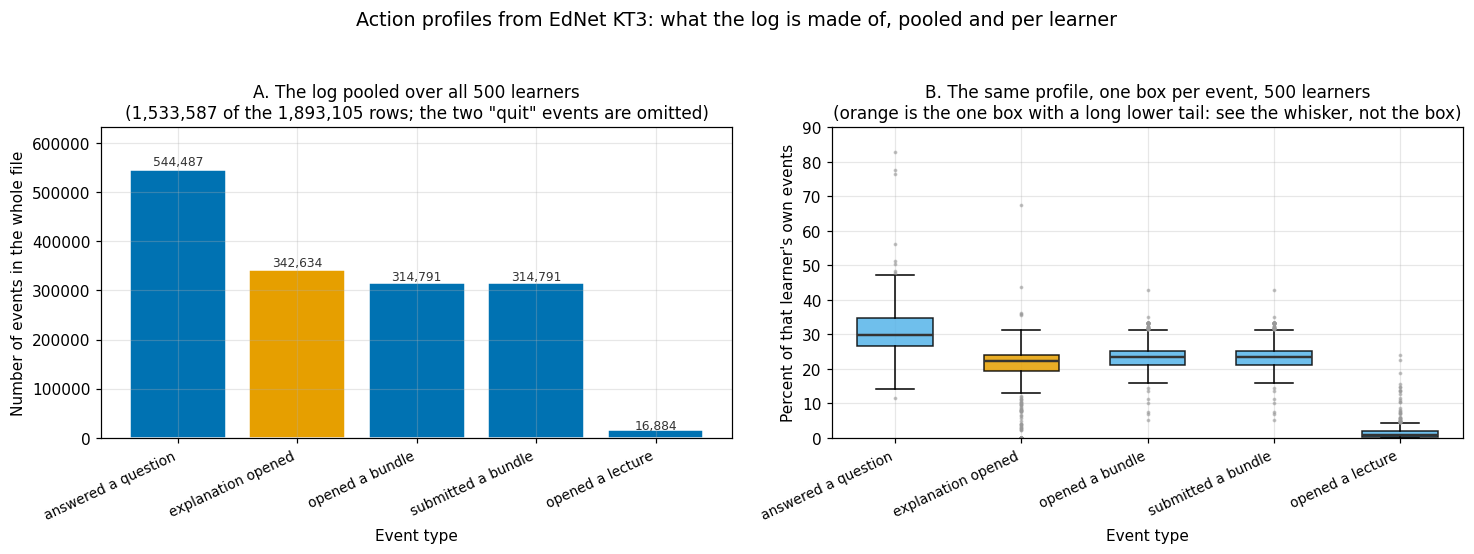

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
order = list(pooled.sort_values(ascending=False).index)
ax.bar(range(len(order)), [counts[e].sum() for e in order],
       color=[BLUE if e != 'enter_e' else ORANGE for e in order], edgecolor='white')
for i, e in enumerate(order):
    ax.text(i, counts[e].sum() * 1.02, format(int(counts[e].sum()), ','),
            ha='center', fontsize=8, color=BLACK)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([LABEL[e] for e in order], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Number of events in the whole file')
ax.set_xlabel('Event type')
ax.set_ylim(0, counts.sum().max() * 1.16)
ax.set_title('A. The log pooled over all 500 learners\n(1,533,587 of the 1,893,105 rows; the two "quit" events are omitted)')

ax = axes[1]
data = [share[e].values for e in order]
bp = ax.boxplot(data, vert=True, widths=0.6, patch_artist=True,
                medianprops=dict(color=BLACK, linewidth=1.6),
                flierprops=dict(marker='.', markersize=3, markerfacecolor=GREY,
                                markeredgecolor=GREY, alpha=0.5))
for patch, e in zip(bp['boxes'], order):
    patch.set_facecolor(ORANGE if e == 'enter_e' else SKY)
    patch.set_alpha(0.85)
ax.set_xticklabels([LABEL[e] for e in order], rotation=25, ha='right', fontsize=9)
ax.set_ylabel("Percent of that learner's own events")
ax.set_xlabel('Event type')
ax.set_title('B. The same profile, one box per event, 500 learners\n'
             '(orange is the one box with a long lower tail: see the whisker, not the box)')
ax.set_ylim(0, 90)

fig.suptitle('Action profiles from EdNet KT3: what the log is made of, pooled and per learner',
             fontsize=12.5, y=1.04)
plt.tight_layout()
plt.show()

**Interpretation prompt.** Panel A is the log. Panel B is the argument.

1. `opened a bundle` and `submitted a bundle` have **identical** counts and identical boxes, because in this app one implies the other. A profile with both columns has one column of information and two columns of width. Look back at any dashboard you have seen this semester and ask how many of its bars were structurally tied to each other.
2. Most of these boxes are narrow. The middle half of learners spend between 21.0 and 25.2 percent of their events opening bundles. **Before you call that a finding about consistent learners, ask what else would produce it.** The instrument: the app moves you from bundle to bundle on rails, so the ratio of opens to answers is close to fixed by design. The setting: this is test preparation, where the format is the point. Only after both of those does anything about a person become a candidate.
3. The orange box is the interesting one, and not because it is wide. Its middle half is narrow too, 19.4 to 24.1 percent, but its tenth percentile is **4.0** percent. The spread is all in a lower tail: for most learners the explanation share is pinned near a fifth of the log, and a minority sit far below it. Write down your first hypothesis about what separates the tail from the rest. Section 5 will test it, and your hypothesis will probably be wrong, which is the most useful thing a hypothesis can do.
4. 42 of 500 learners never opened an explanation and 91 never opened a lecture. If you dropped those learners to make the averages tidier, which direction would every explanation statistic in this notebook move, and by roughly how much?

### ✏️ Your turn 1

Put one learner against the class. Change `FOCUS_LEARNER` to any id in the file and rerun. The default works as is, so you can also just run it.

Learner ids look like `u1`, `u170`, `u2417`. The cell prints a few valid ones for you.

In [7]:
# ✏️ TODO: change this to any learner id in the file, then rerun the cell.
FOCUS_LEARNER = 'u170'

valid = list(counts.index)
print('Some valid ids to try:', ', '.join(valid[:6]), '...  (%d learners in total)' % len(valid))
print()

if FOCUS_LEARNER not in counts.index:
    print('%r is not in this file. Pick one from the list above.' % FOCUS_LEARNER)
else:
    focus = share.loc[FOCUS_LEARNER]
    table = pd.DataFrame({
        'events': counts.loc[FOCUS_LEARNER],
        '%s (%%)' % FOCUS_LEARNER: focus.round(1),
        'class median (%)': share.median().round(1),
        'difference': (focus - share.median()).round(1),
    })
    table.index = [LABEL[e] for e in table.index]
    print('Profile of %s against the median of all 500 learners' % FOCUS_LEARNER)
    print(table.to_string())
    print()
    print('%s logged %s events in total. %.0f percent of the 500 learners logged fewer.'
          % (FOCUS_LEARNER, format(int(counts.loc[FOCUS_LEARNER].sum()), ','),
             100 * (counts.sum(axis=1) < counts.loc[FOCUS_LEARNER].sum()).mean()))
    print()
    print('A percentage and a count say different things. Read both before you say anything')
    print('about this person, and remember that neither of them is a sentence about a mind.')

Some valid ids to try: u1, u10, u100, u101, u102, u103 ...  (500 learners in total)

Profile of u170 against the median of all 500 learners
                     events  u170 (%)  class median (%)  difference
opened a bundle          71      22.3              23.4        -1.0
answered a question      95      29.9              29.8         0.1
submitted a bundle       71      22.3              23.4        -1.0
explanation opened       59      18.6              22.3        -3.8
opened a lecture         22       6.9               0.8         6.1

u170 logged 318 events in total. 32 percent of the 500 learners logged fewer.

A percentage and a count say different things. Read both before you say anything
about this person, and remember that neither of them is a sentence about a mind.


## 📊 3. Cutting a stream into sessions, and admitting it is a choice

The file has no session column. It has a continuous stream of timestamps per learner, running over fifteen months. Almost every claim anyone wants to make about tutor use ("a typical study session", "how much they get through in a sitting") needs sessions, so almost every analyst invents them.

The standard method is a **gap rule**: when the silence between two consecutive actions by the same person exceeds some threshold, call it a new session. The threshold is not in the data. Somebody picks it.

Look at the silences first.

Silences between consecutive actions by the same learner: 1,892,605 gaps



  percentile   seconds        in human units
     1.0             0.03     0.0 s
    10.0             0.06     0.1 s
    25.0             0.98     1.0 s
    50.0             4.70     4.7 s
    75.0            18.54     18.5 s
    90.0            53.22     53.2 s
    95.0           116.94     1.9 min
    99.0          4522.62     75.4 min
    99.9        257710.26     71.6 hours

Share of all silences longer than a candidate threshold:
     1 minutes : 170,683 gaps  (9.018% of all silences)
     5 minutes :  48,078 gaps  (2.540% of all silences)
    10 minutes :  32,920 gaps  (1.739% of all silences)
    15 minutes :  28,352 gaps  (1.498% of all silences)
    30 minutes :  23,310 gaps  (1.232% of all silences)
    60 minutes :  19,926 gaps  (1.053% of all silences)
   120 minutes :  17,035 gaps  (0.900% of all silences)

Two things to check on the shape, because both matter for the rule:
   share of silences under 0.2 s          : 0.177   (the machine)
   share between 0.2 s and 1 s    

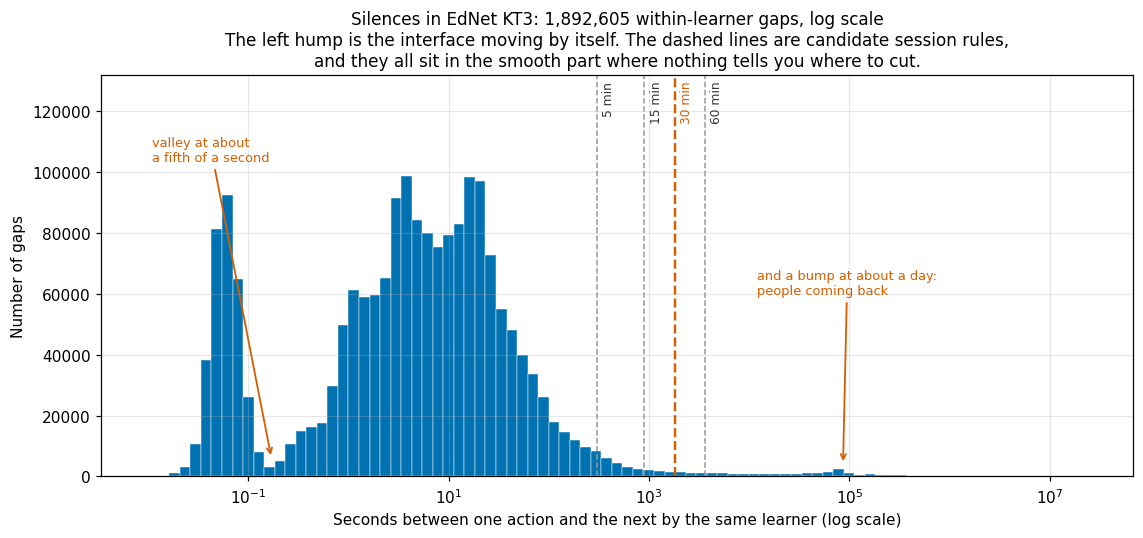

In [8]:
gaps = gap_s.dropna()
print('Silences between consecutive actions by the same learner: %s gaps' % format(len(gaps), ','))
print()
pct = [1, 10, 25, 50, 75, 90, 95, 99, 99.9]
vals = np.percentile(gaps, pct)
print('  percentile   seconds        in human units')
for p, v in zip(pct, vals):
    if v < 90:
        human = '%.1f s' % v
    elif v < 5400:
        human = '%.1f min' % (v / 60)
    else:
        human = '%.1f hours' % (v / 3600)
    print('   %5.1f       %10.2f     %s' % (p, v, human))
print()
print('Share of all silences longer than a candidate threshold:')
for m in [1, 5, 10, 15, 30, 60, 120]:
    print('   %3d minutes : %7s gaps  (%.3f%% of all silences)'
          % (m, format(int((gaps > m * 60).sum()), ','), (gaps > m * 60).mean() * 100))
print()
print('Two things to check on the shape, because both matter for the rule:')
print('   share of silences under 0.2 s          : %.3f   (the machine)' % (gaps < 0.2).mean())
print('   share between 0.2 s and 1 s            : %.3f   (a genuine dip)'
      % (((gaps >= 0.2) & (gaps < 1)).mean()))
print('   so there IS a valley, and it is at a fifth of a second.')
print()
print('   And in the range where a session rule has to live, counts per band:')
for lo, hi in [(5, 15), (15, 30), (30, 60), (60, 120), (120, 360), (360, 720), (720, 1440)]:
    n = int(((gaps >= lo * 60) & (gaps < hi * 60)).sum())
    print('      %5d to %5d minutes : %7s gaps' % (lo, hi, format(n, ',')))
print('   It falls, then turns and rises again toward a day. That rise is people coming')
print('   back tomorrow, and it is the closest thing to a natural boundary in this file.')

fig, ax = plt.subplots(figsize=(10.5, 5.0))
positive = gaps[gaps > 0]
bins = np.logspace(np.log10(0.01), np.log10(positive.max()), 90)
ax.hist(positive, bins=bins, color=BLUE, edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_ylim(0, 132000)
ax.annotate('valley at about\na fifth of a second', xy=(0.17, 6000), xytext=(0.011, 112000),
            fontsize=8.5, color=VERMILLION, va='top',
            arrowprops=dict(arrowstyle='->', color=VERMILLION, linewidth=1.2))
ax.annotate('and a bump at about a day:\npeople coming back', xy=(86400, 4000),
            xytext=(12000, 60000), fontsize=8.5, color=VERMILLION,
            arrowprops=dict(arrowstyle='->', color=VERMILLION, linewidth=1.2))
for m, colour in [(5, GREY), (15, GREY), (30, VERMILLION), (60, GREY)]:
    ax.axvline(m * 60, color=colour, linestyle='--', linewidth=1.6 if m == 30 else 1.0)
    ax.text(m * 60 * 1.14, 130000, '%d min' % m, rotation=90,
            va='top', fontsize=8, color=VERMILLION if m == 30 else BLACK)
ax.set_xlabel('Seconds between one action and the next by the same learner (log scale)')
ax.set_ylabel('Number of gaps')
ax.set_title('Silences in EdNet KT3: 1,892,605 within-learner gaps, log scale\n'
             'The left hump is the interface moving by itself. The dashed lines are candidate session rules,\n'
             'and they all sit in the smooth part where nothing tells you where to cut.')
plt.tight_layout()
plt.show()

**Interpretation prompt.** Read the shape before you read anyone's threshold.

1. The tall hump on the far left peaks at roughly a **sixteenth of a second**, and 17.7 percent of all silences in this file are under a fifth of a second. Say what physical event produces a gap that short, and then say what it does to any statistic that averages "time between actions" over all rows.
2. **There is a valley, and it is in the wrong place.** The clear separation in this distribution sits at about 0.2 seconds, and what it separates is the machine from the person, not one study session from the next. Everywhere a session rule could plausibly go, from a few minutes to a couple of hours, the curve just slides downward with no boundary in it. What does that mean for the claim that a session rule *discovers* sessions rather than *defines* them?
3. The one other feature worth naming is the rise after about six hours, peaking near a day. That is people coming back tomorrow, and it is the only thing in this file that behaves like a natural unit. Nobody uses a 24 hour session rule. Say why not, and what you would lose if you did.
4. Only 1.23 percent of silences exceed 30 minutes, and 1.05 percent exceed an hour. Those two numbers are close together, and the number of sessions they produce is not. Predict, before Section 3.1, whether a 5 minute rule and a 60 minute rule would give you roughly the same picture of a study session.
5. If you were the analyst who had to pick, what evidence outside this file would you want? Name a person you could ask.

### 3.1 A rule, applied, and then interrogated

We state the rule, apply it, and report the headline. Then, because a headline that depends on a choice is only half a finding, we move the choice and report how far the headline goes with it.

> **Session rule.** A new session begins when a learner's first ever action occurs, or when more than **30 minutes** pass since that learner's previous action.

Thirty minutes is common in the literature and it is still a choice. The next cell computes the headline; the cell after it moves the rule.

In [9]:
def sessionise(gap_minutes):
    # Return a session id per row under a stated gap rule, plus one row per session.
    starts_new = gap_s.isna() | (gap_s > gap_minutes * 60)
    sid = starts_new.cumsum()
    per_session = pd.DataFrame({
        'user_id': actions['user_id'].values,
        'session': sid.values,
        'timestamp': actions['timestamp'].values,
        'is_bundle_open': (actions['event'] == 'enter_b').values,
    }).groupby('session').agg(user_id=('user_id', 'first'),
                              n_actions=('timestamp', 'size'),
                              minutes=('timestamp', lambda s: (s.max() - s.min()) / 1000 / 60),
                              bundles=('is_bundle_open', 'sum'))
    return sid, per_session


GAP_MINUTES = 30
session_id, sessions = sessionise(GAP_MINUTES)

per_learner = sessions.groupby('user_id').agg(
    n_sessions=('n_actions', 'size'),
    median_actions=('n_actions', 'median'),
    median_minutes=('minutes', 'median'),
    median_bundles=('bundles', 'median'))

print('Under a %d minute rule:' % GAP_MINUTES)
print('   sessions in the whole file        : %s' % format(len(sessions), ','))
print('   learners with at least one session: %d' % per_learner.shape[0])
print()
print('Computed per learner first, then summarised across the 500 learners:')
print('   median sessions per learner       : %.0f' % per_learner['n_sessions'].median())
print('   median actions in a session       : %.2f' % per_learner['median_actions'].median())
print('   median minutes in a session       : %.2f' % per_learner['median_minutes'].median())
print('   HEADLINE, median bundles attempted in a sitting: %.2f'
      % per_learner['median_bundles'].median())
print()
print('For contrast, the number you get if you forget that rows nest inside people and')
print('just average over all %s sessions:' % format(len(sessions), ','))
print('   median bundles per session, pooled over sessions: %.2f' % sessions['bundles'].median())
print('   mean   bundles per session, pooled over sessions: %.2f' % sessions['bundles'].mean())
print('The pooled mean is pulled by the busiest learners, who contribute the most sessions.')

Under a 30 minute rule:
   sessions in the whole file        : 23,810
   learners with at least one session: 500

Computed per learner first, then summarised across the 500 learners:
   median sessions per learner       : 19
   median actions in a session       : 44.25
   median minutes in a session       : 16.02
   HEADLINE, median bundles attempted in a sitting: 8.75

For contrast, the number you get if you forget that rows nest inside people and
just average over all 23,810 sessions:
   median bundles per session, pooled over sessions: 8.00
   mean   bundles per session, pooled over sessions: 13.22
The pooled mean is pulled by the busiest learners, who contribute the most sessions.


SENSITIVITY OF THE HEADLINE TO THE SESSION RULE
                sessions in file  median sessions per learner  median actions per session  median minutes per session  HEADLINE bundles per sitting  % sessions of one action
gap rule (min)                                                                                                                                                               
5                          48578                         37.0                       22.00                        6.54                          5.00                       9.7
10                         33420                         27.0                       33.00                       10.59                          7.00                       4.3
15                         28852                         24.0                       38.00                       13.02                          7.75                       2.6
20                         26431                         22.0                     

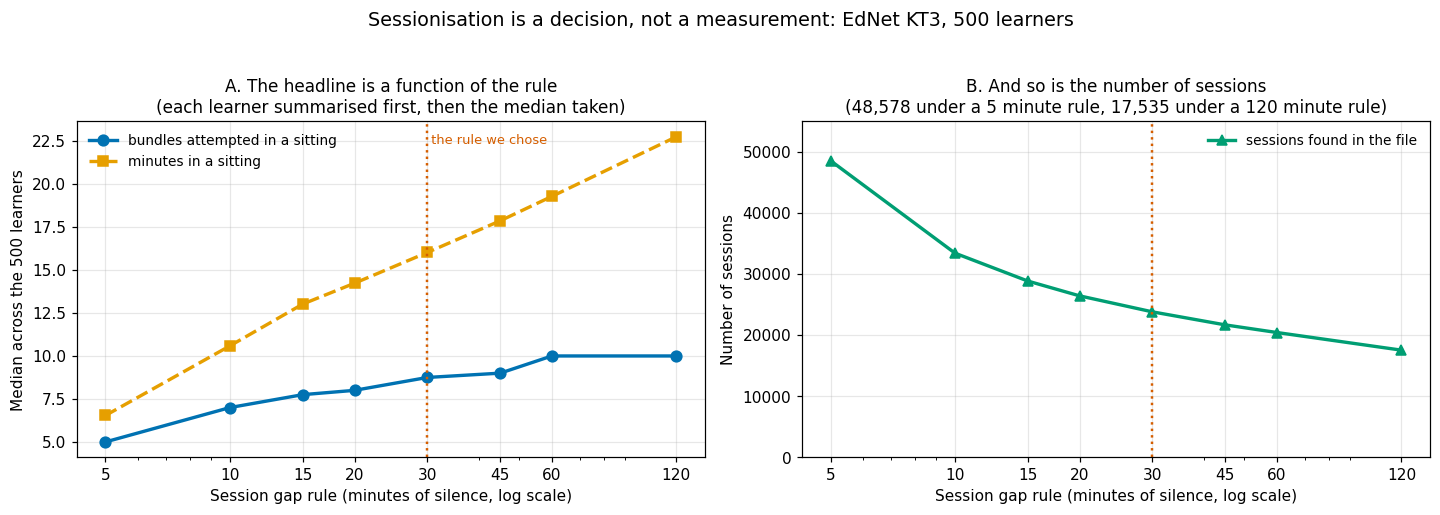

In [10]:
rows = []
for m in [5, 10, 15, 20, 30, 45, 60, 120]:
    _, s = sessionise(m)
    pl = s.groupby('user_id').agg(n=('n_actions', 'size'),
                                  a=('n_actions', 'median'),
                                  mi=('minutes', 'median'),
                                  b=('bundles', 'median'))
    rows.append({'gap rule (min)': m,
                 'sessions in file': len(s),
                 'median sessions per learner': pl['n'].median(),
                 'median actions per session': pl['a'].median(),
                 'median minutes per session': round(pl['mi'].median(), 2),
                 'HEADLINE bundles per sitting': pl['b'].median(),
                 '% sessions of one action': round((s['n_actions'] == 1).mean() * 100, 1)})
sensitivity = pd.DataFrame(rows).set_index('gap rule (min)')
print('SENSITIVITY OF THE HEADLINE TO THE SESSION RULE')
print(sensitivity.to_string())
print()
h = sensitivity['HEADLINE bundles per sitting']
print('The headline "a typical sitting is about %.1f bundles" moves from %.1f to %.1f'
      % (h.loc[30], h.min(), h.max()))
print('across defensible rules, a factor of %.1f. The minutes figure moves from %.1f to %.1f,'
      % (h.max() / h.min(), sensitivity['median minutes per session'].min(),
         sensitivity['median minutes per session'].max()))
print('a factor of %.1f. Nothing about the learners changed between those rows.'
      % (sensitivity['median minutes per session'].max()
         / sensitivity['median minutes per session'].min()))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.5))
x = sensitivity.index.values

ax = axes[0]
ax.plot(x, sensitivity['HEADLINE bundles per sitting'], marker='o', color=BLUE,
        linewidth=2.2, markersize=7, label='bundles attempted in a sitting')
ax.plot(x, sensitivity['median minutes per session'], marker='s', color=ORANGE,
        linewidth=2.2, markersize=7, linestyle='--', label='minutes in a sitting')
ax.axvline(30, color=VERMILLION, linestyle=':', linewidth=1.6)
ax.text(30, ax.get_ylim()[1] * 0.97, ' the rule we chose', fontsize=8.5,
        color=VERMILLION, va='top')
ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in x])
ax.set_xlabel('Session gap rule (minutes of silence, log scale)')
ax.set_ylabel('Median across the 500 learners')
ax.set_title('A. The headline is a function of the rule\n(each learner summarised first, then the median taken)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(x, sensitivity['sessions in file'], marker='^', color=GREEN, linewidth=2.2,
        markersize=7, label='sessions found in the file')
ax.axvline(30, color=VERMILLION, linestyle=':', linewidth=1.6)
ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in x])
ax.set_xlabel('Session gap rule (minutes of silence, log scale)')
ax.set_ylabel('Number of sessions')
ax.set_ylim(0, 55000)
ax.set_title('B. And so is the number of sessions\n(48,578 under a 5 minute rule, 17,535 under a 120 minute rule)')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('Sessionisation is a decision, not a measurement: EdNet KT3, 500 learners',
             fontsize=12.5, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation prompt.** This is the most portable lesson in the notebook, so give it a minute.

1. Write the headline as a vendor would print it: *"learners get through about 9 question screens in a typical sitting."* Now write the honest version, which has to contain the phrase "under a 30 minute rule". Say which of the two you have ever seen in a paper.
2. Panel A shows the bundles figure doubling, from 5.0 to 10.0, and the minutes figure rising by a factor of 3.5, from 6.5 to 22.8, across the range. **Neither the learners nor the log changed.** What does that tell you about comparing a session statistic in one paper against a session statistic in another?
3. Under a 5 minute rule, 9.7 percent of sessions contain exactly one action. Under a 30 minute rule, 1.2 percent do. If your analysis excluded one-action sessions as noise, which rule would make the biggest difference to what you excluded, and would you have noticed?
4. **The instrument first.** This app pushes notifications and runs on a phone. Name two things about phone use that make a fixed gap rule a poor description of a study session, and say what you would need in the file to do better. Only then think about whether any of this is about how the person studies.

### ✏️ Your turn 2

Move the rule and watch the headline move. The cell ships with **10 minutes**, deliberately different from the notebook's 30, so that a number changes on your first run.

In [11]:
# ✏️ TODO: change this and rerun. Try 5, then 30, then 120.
MY_GAP_MINUTES = 10

_, my_sessions = sessionise(MY_GAP_MINUTES)
mine = my_sessions.groupby('user_id').agg(n=('n_actions', 'size'),
                                          b=('bundles', 'median'),
                                          mi=('minutes', 'median'))
print('Your rule: a new session after %d minutes of silence.' % MY_GAP_MINUTES)
print("The notebook's rule: %d minutes." % GAP_MINUTES)
print()
print('                                     yours     notebook    change')
print('sessions in the file             %9s %12s %9s'
      % (format(len(my_sessions), ','), format(len(sessions), ','),
         format(len(my_sessions) - len(sessions), '+,')))
print('median bundles in a sitting      %9.2f %12.2f %+9.2f'
      % (mine['b'].median(), per_learner['median_bundles'].median(),
         mine['b'].median() - per_learner['median_bundles'].median()))
print('median minutes in a sitting      %9.2f %12.2f %+9.2f'
      % (mine['mi'].median(), per_learner['median_minutes'].median(),
         mine['mi'].median() - per_learner['median_minutes'].median()))
print()
print('Now say, in one sentence you would defend in a viva, which of these two numbers is')
print('a fact about how these 500 people studied.')

Your rule: a new session after 10 minutes of silence.
The notebook's rule: 30 minutes.

                                     yours     notebook    change
sessions in the file                33,420       23,810    +9,610
median bundles in a sitting           7.00         8.75     -1.75
median minutes in a sitting          10.59        16.02     -5.42

Now say, in one sentence you would defend in a viva, which of these two numbers is
a fact about how these 500 people studied.


## 📊 4. Order: what follows what

Profiles count. Regulation, in Winne's account, is about **order**: reviewing feedback you never earned is not evaluation, and planning after you finish is not planning. So look at the order.

The simplest order statistic is the **bigram**: every neighbouring pair of events, with the earlier one in the rows and the later one in the columns, each row divided by its own total. Cell 4 below reads: given that a learner has just done the row event, what did they do next, as a percentage.

Pairs are taken **within a learner only**, so we never count the last action of one person followed by the first action of the next.

Bigram counts, 1,892,605 within-learner pairs:
event      enter_b  respond_q  submit_b  enter_e  quit_e  enter_l  quit_l
event                                                                    
enter_b          0     300162     14629        0       0        0       0
respond_q        0     242889    300162        0    1434        0       2
submit_b     16400          0         0   296962       0     1241       0
enter_e          0       1434         0        0  341200        0       0
quit_e      290966          0         0    44009       0     7374       0
enter_l          0          2         0        0       0        0   16882
quit_l        6944          0         0     1652       0     8261       0

Row percentages: given the row event, what happened next (%)
event      enter_b  respond_q  submit_b  enter_e  quit_e  enter_l  quit_l
event                                                                    
enter_b        0.0       95.4       4.6      0.0     0.0      0.0     0.0
res

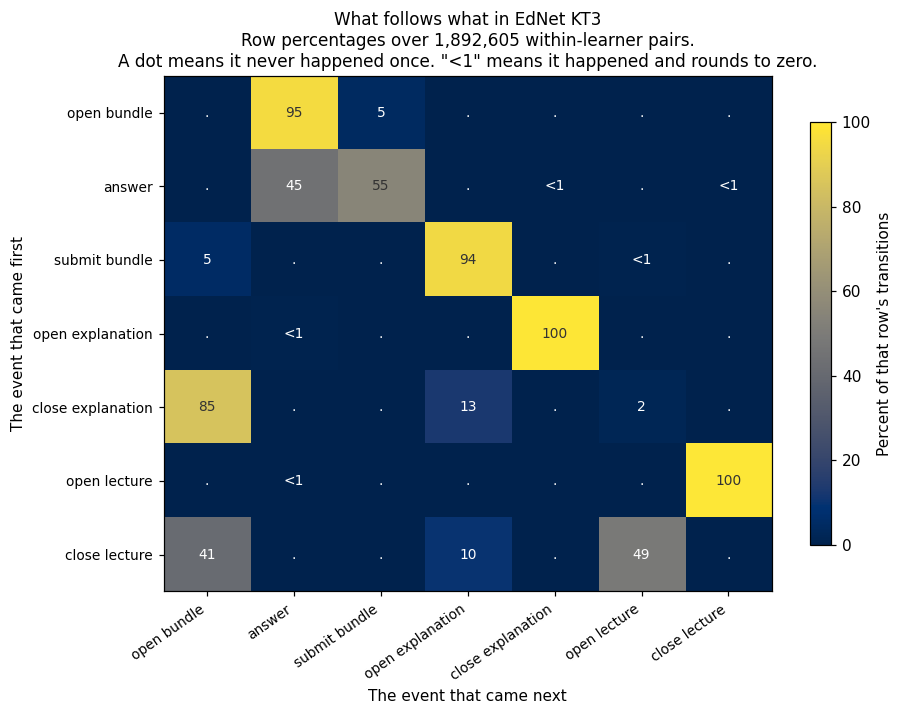

In [12]:
STATE_ORDER = ['enter_b', 'respond_q', 'submit_b', 'enter_e', 'quit_e', 'enter_l', 'quit_l']
PRETTY = {'enter_b': 'open bundle', 'respond_q': 'answer', 'submit_b': 'submit bundle',
          'enter_e': 'open explanation', 'quit_e': 'close explanation',
          'enter_l': 'open lecture', 'quit_l': 'close lecture'}

next_event = actions['event'].shift(-1)
same_learner = actions['user_id'] == actions['user_id'].shift(-1)
pairs = pd.crosstab(actions['event'][same_learner], next_event[same_learner])
pairs = pairs.reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)
transition = pairs.div(pairs.sum(axis=1), axis=0) * 100

print('Bigram counts, %s within-learner pairs:' % format(int(pairs.values.sum()), ','))
print(pairs.to_string())
print()
print('Row percentages: given the row event, what happened next (%)')
print(transition.round(1).to_string())

fig, ax = plt.subplots(figsize=(8.6, 6.6))
im = ax.imshow(transition.values, cmap='cividis', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(STATE_ORDER)))
ax.set_xticklabels([PRETTY[s] for s in STATE_ORDER], rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(STATE_ORDER)))
ax.set_yticklabels([PRETTY[s] for s in STATE_ORDER], fontsize=9)
for i in range(len(STATE_ORDER)):
    for j in range(len(STATE_ORDER)):
        v = transition.values[i, j]
        n = pairs.values[i, j]
        if n == 0:
            label = '.'          # never once happened
        elif v < 0.5:
            label = '<1'         # happened, but rounds to zero
        else:
            label = '%.0f' % v
        ax.text(j, i, label, ha='center', va='center', fontsize=9,
                color='white' if v < 55 else BLACK)
ax.set_xlabel('The event that came next')
ax.set_ylabel('The event that came first')
ax.set_title('What follows what in EdNet KT3\n'
             'Row percentages over 1,892,605 within-learner pairs.\n'
             'A dot means it never happened once. "<1" means it happened and rounds to zero.')
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label('Percent of that row\'s transitions')
ax.grid(False)
plt.tight_layout()
plt.show()

**Interpretation prompt.** Most of this grid is empty, and the empty parts are the interesting parts.

1. Count the cells that are not a dot. There are **19 of 49**, because the app allows only certain orders. **A dot here is a fact about the software, not about people.** In a made-up dataset a striking empty row is a discovery; in a real product log it is usually a specification. Notice also the five cells marked `<1`. They happened, 1,434 times in two of them, and a grid rounded to whole percentages would have shown you a zero. Rounding is a choice too.
2. `submit bundle` is followed by `open explanation` **94.4 percent** of the time. Write the two competing readings of that number, one in which these are curious learners who always check the explanation, and one in which they never chose anything at all. Then say what in the file could settle it. It is not a new column: it is the difference between two numbers you already have, and Section 5 subtracts them.
3. `answer` is followed by `answer` 44.6 percent of the time. Some of that is multi-question bundles and some of it is somebody changing their mind, as `u170` did in Section 1.1. The bigram cannot distinguish those. What would you need to add to the matrix to make it able to?
4. `close explanation` is followed by `open explanation` **12.9 percent** of the time. Hold on to that cell. Section 7 will show that it is not what it looks like either.

## 📊 5. The first logging artifact: the explanation nobody asked for

Here is a study you could write this afternoon, and it would look reasonable.

> *Explanation viewing as a self-regulation indicator.* We operationalise help seeking as the number of explanation screens a learner opened. Learners in the top quartile of explanation use are compared with the bottom quartile on ...

Cell 4 already told you something is wrong with it, and the clock will finish the job. If an explanation opens **94.4 percent** of the times a bundle is submitted, the question is not why learners open explanations so often. The question is whether they open them at all.

**Timing is what settles it.** The next cell measures the seconds between submitting a bundle and the explanation appearing.

Explanation screens that appear immediately after a submit: 296,962
   of which the explanation is for the bundle just submitted: 99.35%

Seconds from submitting the bundle to the explanation appearing:
   overall     median 0.077 s   share under 0.2 s 60.7%   share under 2 s 90.9%
   mobile   n= 182,748  median 0.057 s   share under 0.2 s 98.6%
   web      n= 114,214  median 1.317 s   share under 0.2 s 0.0%

Human simple reaction time to a visual signal is about 0.2 to 0.25 seconds, and that is
before deciding anything. A median of 0.057 s on mobile is the application, not a person.


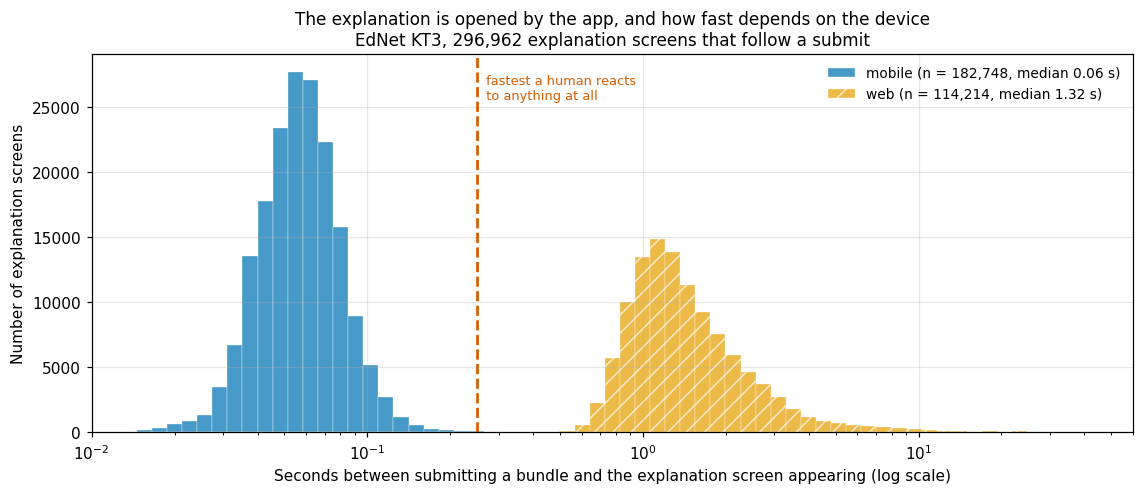

In [13]:
prev_event = actions['event'].shift()
prev_num = actions['item_num'].shift()
prev_time = actions['timestamp'].shift()
same_prev = actions['user_id'] == actions['user_id'].shift()

opened_after_submit = ((actions['event'] == 'enter_e') & same_prev
                       & (prev_event == 'submit_b') & (prev_num == actions['item_num']))
latency = ((actions['timestamp'] - prev_time) / 1000.0)[
    (actions['event'] == 'enter_e') & same_prev & (prev_event == 'submit_b')]
latency_platform = actions['platform'][latency.index]

print('Explanation screens that appear immediately after a submit: %s'
      % format(int(latency.shape[0]), ','))
print('   of which the explanation is for the bundle just submitted: %.2f%%'
      % ((actions['item_num'][latency.index] == prev_num[latency.index]).mean() * 100))
print()
print('Seconds from submitting the bundle to the explanation appearing:')
print('   overall     median %.3f s   share under 0.2 s %.1f%%   share under 2 s %.1f%%'
      % (latency.median(), (latency < 0.2).mean() * 100, (latency < 2).mean() * 100))
for p in ['mobile', 'web']:
    lp = latency[latency_platform == p]
    print('   %-8s n=%8s  median %.3f s   share under 0.2 s %.1f%%'
          % (p, format(len(lp), ','), lp.median(), (lp < 0.2).mean() * 100))
print()
print('Human simple reaction time to a visual signal is about 0.2 to 0.25 seconds, and that is')
print('before deciding anything. A median of %.3f s on mobile is the application, not a person.'
      % latency[latency_platform == 'mobile'].median())

fig, ax = plt.subplots(figsize=(10.5, 4.6))
bins = np.logspace(np.log10(0.01), np.log10(60), 70)
for p, colour, hatch in [('mobile', BLUE, None), ('web', ORANGE, '//')]:
    lp = latency[(latency_platform == p) & (latency > 0)]
    ax.hist(lp, bins=bins, color=colour, alpha=0.72, hatch=hatch, edgecolor='white',
            linewidth=0.3, label='%s (n = %s, median %.2f s)' % (p, format(len(lp), ','), lp.median()))
ax.axvline(0.25, color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(0.26, ax.get_ylim()[1] * 0.88, ' fastest a human reacts\n to anything at all',
        fontsize=8.5, color=VERMILLION)
ax.set_xscale('log')
ax.set_xlim(0.01, 60)
ax.set_xlabel('Seconds between submitting a bundle and the explanation screen appearing (log scale)')
ax.set_ylabel('Number of explanation screens')
ax.set_title('The explanation is opened by the app, and how fast depends on the device\n'
             'EdNet KT3, 296,962 explanation screens that follow a submit')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation prompt.** Two findings live in that chart and only one of them is about the app.

1. On **mobile**, 98.6 percent of these explanation screens appear within a fifth of a second of the submit. Nobody decided anything. The screen is part of the submit. Rewrite the imaginary abstract at the top of this section so that it says what "number of explanations opened" actually measures.
2. On **web**, the median is 1.32 seconds and the share under 0.2 seconds rounds to zero: 18 screens out of 114,214, about one in six thousand. Same product, same behaviour, different client. Suppose you had used that latency as a measure of how quickly a learner turns to help. What would your published finding have been about?
3. This is the shape of a whole class of error, so name it in your own words: a variable that looks like a decision and is a **default**. Give an example from a learning platform you have used or built.
4. **What would you have to know that is not in this file** to be sure which explanations were chosen? Write down the question, and note that it is a question for a product manager, not a statistician.

Across the 500 learners:
   explanation screens opened vs bundles submitted
      Pearson  r = 0.9825   (on raw counts, which are heavily right skewed)
      Spearman r = 0.9953   (on ranks, which is the one to trust here)
   explanations per bundle submitted, per learner:
      median 1.008, 10th percentile 0.125, 90th percentile 1.191

A Spearman of 0.995 means that ranking learners by "explanation use" reproduces the
ranking by "how much they used the app" almost exactly. It is a volume measure.

And the 42 learners who never opened one? Look at their volume before you theorise:
   their total events: smallest 7, median 21, largest 40
   across all 500 learners the median is 1,051 events and the largest is 49,556.
   learners with 100 or more events who never opened an explanation: 0

Among the 409 learners with 100 or more events, the explanation share is pinned:
   5th percentile 18.3%, median 22.9%, 90th percentile 26.0%
   and only 3 of them sit below 10%.
So the long lower tail

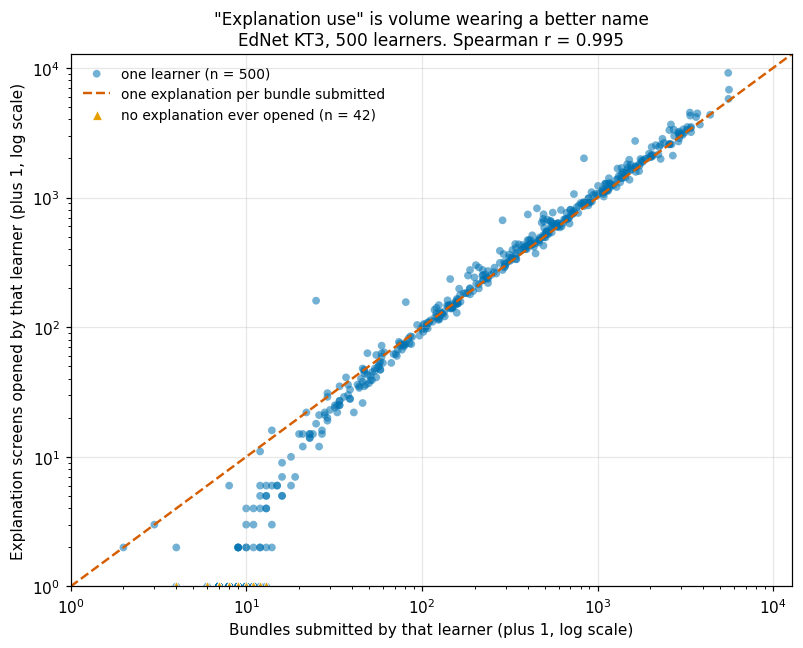

In [14]:
opens = counts['enter_e']
submits = counts['submit_b']
pearson = np.corrcoef(opens, submits)[0, 1]
ranks = pd.DataFrame({'o': opens, 's': submits}).rank()
spearman = np.corrcoef(ranks['o'], ranks['s'])[0, 1]
ratio = (opens / submits.replace(0, np.nan)).dropna()

print('Across the 500 learners:')
print('   explanation screens opened vs bundles submitted')
print('      Pearson  r = %.4f   (on raw counts, which are heavily right skewed)' % pearson)
print('      Spearman r = %.4f   (on ranks, which is the one to trust here)' % spearman)
print('   explanations per bundle submitted, per learner:')
print('      median %.3f, 10th percentile %.3f, 90th percentile %.3f'
      % (ratio.median(), ratio.quantile(.10), ratio.quantile(.90)))
print()
print('A Spearman of %.3f means that ranking learners by "explanation use" reproduces the' % spearman)
print('ranking by "how much they used the app" almost exactly. It is a volume measure.')
print()

total_events = counts.sum(axis=1)
never = counts.index[counts['enter_e'] == 0]
print('And the %d learners who never opened one? Look at their volume before you theorise:'
      % len(never))
print('   their total events: smallest %d, median %d, largest %d'
      % (total_events[never].min(), total_events[never].median(), total_events[never].max()))
print('   across all 500 learners the median is %s events and the largest is %s.'
      % (format(int(total_events.median()), ','), format(int(total_events.max()), ',')))
print('   learners with 100 or more events who never opened an explanation: %d'
      % int(((counts['enter_e'] == 0) & (total_events >= 100)).sum()))
print()
regulars = share['enter_e'][total_events >= 100]
print('Among the %d learners with 100 or more events, the explanation share is pinned:' % len(regulars))
print('   5th percentile %.1f%%, median %.1f%%, 90th percentile %.1f%%'
      % (regulars.quantile(.05), regulars.median(), regulars.quantile(.90)))
print('   and only %d of them sit below 10%%.' % int((regulars < 10).sum()))
print('So the long lower tail in Section 2 was not a kind of learner. It was people with')
print('almost no log at all. Once a person uses the app, the app opens explanations for them.')

fig, ax = plt.subplots(figsize=(7.4, 6.0))
ax.scatter(submits + 1, opens + 1, s=26, color=BLUE, alpha=0.55, edgecolor='none',
           label='one learner (n = 500)')
lim = [1, max(submits.max(), opens.max()) * 1.4]
ax.plot(lim, lim, color=VERMILLION, linestyle='--', linewidth=1.6,
        label='one explanation per bundle submitted')
zero = opens == 0
ax.scatter(submits[zero] + 1, opens[zero] + 1, s=42, color=ORANGE, marker='^',
           edgecolor='white', linewidth=0.5, label='no explanation ever opened (n = %d)' % int(zero.sum()))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Bundles submitted by that learner (plus 1, log scale)')
ax.set_ylabel('Explanation screens opened by that learner (plus 1, log scale)')
ax.set_title('"Explanation use" is volume wearing a better name\n'
             'EdNet KT3, 500 learners. Spearman r = %.3f' % spearman)
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation prompt.**

1. The points sit on the diagonal because the app puts them there. **Any measure that correlates at 0.995 with total activity is total activity.** Name one other learning-analytics measure you have met this semester that might have this property, and say how you would check.
2. **Now go back and check what you predicted in Section 2.** The long lower tail in the orange box was, you were invited to guess, a kind of learner. The printout says otherwise: all 42 learners with no explanation event have between 7 and 40 logged events in total, against a class median of 1,051, and **not one** learner with 100 or more events is among them. Among the 409 regular users the explanation share sits between 18.3 and 26.0 percent from the 5th to the 90th percentile. The tail was people with almost no log.
3. That is worth naming as a general failure. A measure that behaves differently for people with little data will produce a "group" that is really a sample-size artifact, and it will look like a finding. Where else this semester have you seen a group defined, in effect, by how much of it there was to measure?
4. Suppose a dashboard ranked these 500 people on "explanation use" and showed the bottom decile to a tutor. Write the sentence the tutor would say out loud, then write what the data actually supports. Notice how far apart they are.
5. So what would a defensible measure of engaging with an explanation look like, given only this file? You already have the answer from Section 1.1. It is the clock.

## 📊 6. The second logging artifact: the answer you have already been shown

Now the artifact that the field falls for most often, and the one this file lets you see cleanly.

The natural study, the one everybody wants to run on a tutor log, is: **do learners who use the help do better?** You compare accuracy on items where help was consumed against accuracy on items where it was not.

This extract has **no answer key**, so you literally cannot run it. Good. Because if you could, here is what you would have been measuring.

The reasoning has three steps and the notebook does each one out loud:

1. How often does a learner answer the same question more than once?
2. Of those repeats, how many come after the learner has already been shown that bundle's explanation?
3. Do those post-explanation answers look like knowledge, or like reproduction?

In [15]:
# Episode-level bundle identity, restricted to rows inside their own learner's episode.
inside = actions[in_own_episode & (actions['episode'] > 0)]
bundle_of_episode = actions.loc[actions['event'] == 'enter_b'].set_index('episode')['item_num']

answers = inside[inside['event'] == 'respond_q'].copy()
answers['bundle'] = answers['episode'].map(bundle_of_episode)
answers['answer_number_for_this_learner'] = answers.groupby(['user_id', 'item_num']).cumcount()

# The first time this learner opened the explanation for this bundle.
expl_opens = actions.loc[actions['event'] == 'enter_e', ['user_id', 'item_num', 'timestamp']]
first_expl = expl_opens.groupby(['user_id', 'item_num'])['timestamp'].min()
answers['explanation_first_seen'] = pd.MultiIndex.from_arrays(
    [answers['user_id'], answers['bundle']]).map(first_expl)
answers['already_shown'] = (answers['explanation_first_seen'].notna()
                            & (answers['explanation_first_seen'] < answers['timestamp']))

pairs_lq = answers.groupby(['user_id', 'item_num']).size()
print('STEP 1. Repeats.')
print('   answers in the file                       : %s' % format(len(answers), ','))
print('   distinct learner-and-question pairs       : %s' % format(len(pairs_lq), ','))
print('   pairs answered more than once             : %s  (%.1f%% of pairs)'
      % (format(int((pairs_lq > 1).sum()), ','), (pairs_lq > 1).mean() * 100))
print('   answers that are a repeat of one already given: %s  (%.1f%% of all answers)'
      % (format(int(len(answers) - len(pairs_lq)), ','),
         100 * (len(answers) - len(pairs_lq)) / len(answers)))
print()
print('STEP 2. Was the explanation already shown?')
tab = pd.crosstab(answers['answer_number_for_this_learner'] > 0, answers['already_shown'],
                  margins=True)
tab.index = ['first time this learner answered it', 'a repeat answer', 'All']
tab.columns = ['explanation not yet shown', 'explanation already shown', 'All']
print(tab.to_string())
print()
print('   share of FIRST answers preceded by that explanation : %.2f%%'
      % (answers.loc[answers['answer_number_for_this_learner'] == 0, 'already_shown'].mean() * 100))
print('   share of REPEAT answers preceded by that explanation: %.2f%%'
      % (answers.loc[answers['answer_number_for_this_learner'] > 0, 'already_shown'].mean() * 100))
print('   share of ALL answers preceded by that explanation   : %.2f%%'
      % (answers['already_shown'].mean() * 100))

STEP 1. Repeats.
   answers in the file                       : 544,487
   distinct learner-and-question pairs       : 321,529
   pairs answered more than once             : 98,573  (30.7% of pairs)
   answers that are a repeat of one already given: 222,958  (40.9% of all answers)

STEP 2. Was the explanation already shown?
                                     explanation not yet shown  explanation already shown     All
first time this learner answered it                     317234                       4295  321529
a repeat answer                                         143474                      79484  222958
All                                                     460708                      83779  544487

   share of FIRST answers preceded by that explanation : 1.34%
   share of REPEAT answers preceded by that explanation: 35.65%
   share of ALL answers preceded by that explanation   : 15.39%


**Stop here for a moment.** Just over fifteen percent of every answer in this file was given by somebody who had already been shown the explanation for that bundle. Among repeat answers it is more than a third.

Suppose the answer key existed. You compute accuracy on answers where help had been consumed, compare it with accuracy where it had not, and the help group is dramatically more accurate. You write that explanation viewing supports learning.

**You would have measured the logging convention.** The explanation screen displays the correct option. An answer given after it is an answer given with the answer on the screen a moment ago. The comparison is not between a learner who used help and a learner who did not; it is between somebody seeing a question and somebody re-typing something they were shown.

The direction generalises. Wherever a tutor logs help **before** the outcome it scores, the outcome after help is partly determined by the logging, not by the learner. In systems where the hint contains the answer, the recorded outcome after a hint is structurally low or structurally high depending only on whether the system credits the post-hint attempt. Either way the number is about the system.

We cannot check accuracy here. We can check something almost as good, and it needs no answer key.

STEP 3. Concentration of the chosen option.
   questions with at least 10 independent answers in BOTH conditions: 1,241
   rows behind them: 317,246 at first exposure, 48,440 after the explanation was shown

   share of answers on the single most chosen option, per question:
      first exposure               median 0.551   mean 0.562
      after the explanation shown  median 0.700   mean 0.697
      median difference            +0.136
      questions where it rises     1,013 of 1,241 (81.6%)
      bootstrap 95% interval on the median difference, resampling QUESTIONS:
         [+0.125, +0.145]
      Caveat you must carry: the same 500 learners appear across many questions, so
      questions are not fully independent either and this interval is optimistic.

   Answers per question, which are not the same in the two conditions:
      first exposure               median 67
      after the explanation shown  median 14



   SAME COMPARISON WITH THE SAMPLE SIZE HELD FIXED
      first-exposure answers thinned to match each question's post-explanation count
      median difference                +0.110   (was +0.136 unmatched)
      spread across 25 thinnings       0.0067
      So about 19% of the raw gap was the smaller sample in the second condition.
      The effect survives the correction and it is smaller than it first looked.
      Report the matched number, and note that the bootstrap interval above is
      an interval on the UNMATCHED statistic and does not cover this one.

   And when the answer comes within 24 hours of the explanation (17,225 answers, 191 questions):
      first exposure median 0.496   ->   after the explanation median 0.812
      but the two sides differ in size again: 111 answers per question against 13,
      and thinning the first-exposure side to match lifts its median from 0.496 to 0.527.
      The 0.81 is still far above that, and the gap is smaller than the raw pair sug

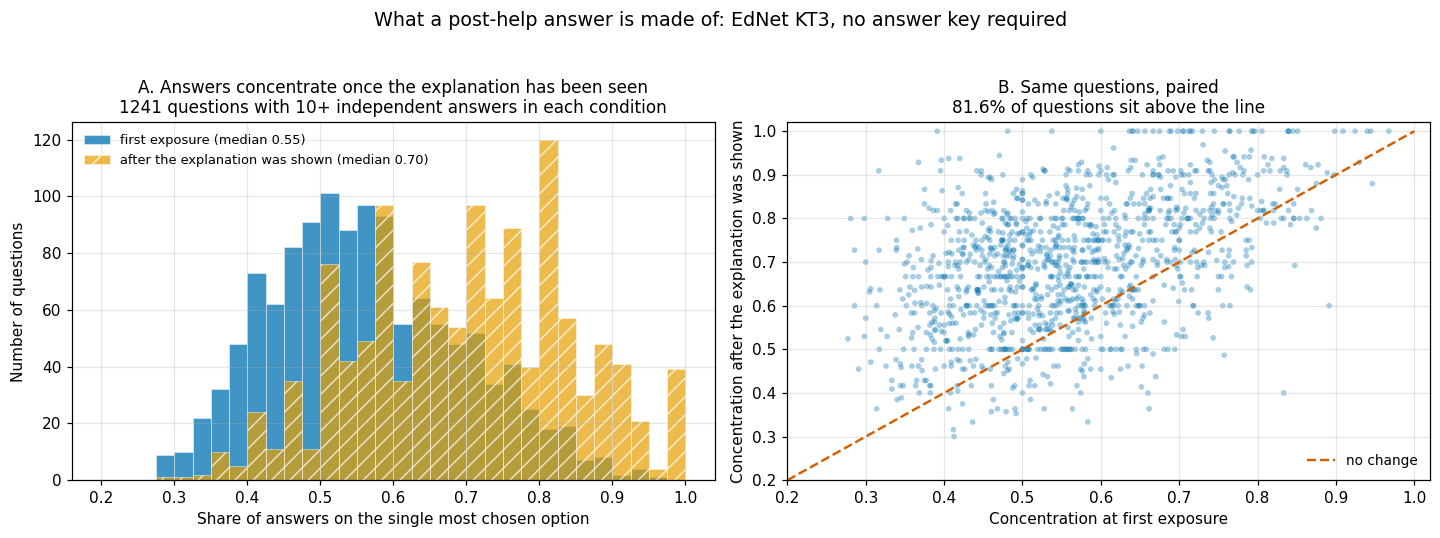

In [16]:
# STEP 3. If a post-explanation answer is reproduction, the chosen options should pile up
# on one option. Concentration needs no answer key.
MIN_ANSWERS_PER_QUESTION = 10

def modal_share(frame):
    # Per question: the share of answers falling on the single most chosen option.
    g = frame.groupby(['item_num', 'user_answer'], observed=True).size().rename('n').reset_index()
    total = g.groupby('item_num')['n'].sum()
    top = g.groupby('item_num')['n'].max()
    keep = total[total >= MIN_ANSWERS_PER_QUESTION].index
    return top[keep] / total[keep]

# One answer per learner per question in each condition, so the rows inside a question are
# 10+ different people and not one person answering ten times.
first_exposure = (answers[~answers['already_shown']]
                  .sort_values('timestamp').drop_duplicates(['user_id', 'item_num']))
after_shown = (answers[answers['already_shown']]
               .sort_values('timestamp').drop_duplicates(['user_id', 'item_num']))

conc_first = modal_share(first_exposure)
conc_after = modal_share(after_shown)
q = conc_first.index.intersection(conc_after.index)
delta = conc_after[q] - conc_first[q]

print('STEP 3. Concentration of the chosen option.')
print('   questions with at least %d independent answers in BOTH conditions: %s'
      % (MIN_ANSWERS_PER_QUESTION, format(len(q), ',')))
print('   rows behind them: %s at first exposure, %s after the explanation was shown'
      % (format(len(first_exposure), ','), format(len(after_shown), ',')))
print()
print('   share of answers on the single most chosen option, per question:')
print('      first exposure               median %.3f   mean %.3f'
      % (conc_first[q].median(), conc_first[q].mean()))
print('      after the explanation shown  median %.3f   mean %.3f'
      % (conc_after[q].median(), conc_after[q].mean()))
print('      median difference            %+.3f' % delta.median())
print('      questions where it rises     %s of %s (%.1f%%)'
      % (format(int((delta > 0).sum()), ','), format(len(delta), ','), (delta > 0).mean() * 100))

rng = np.random.default_rng(8100)
boot = np.array([np.median(delta.values[rng.integers(0, len(delta), len(delta))])
                 for _ in range(4000)])
print('      bootstrap 95% interval on the median difference, resampling QUESTIONS:')
print('         [%+.3f, %+.3f]' % (np.percentile(boot, 2.5), np.percentile(boot, 97.5)))
print('      Caveat you must carry: the same 500 learners appear across many questions, so')
print('      questions are not fully independent either and this interval is optimistic.')
print()

# ---------------------------------------------------------------------------
# The statistic itself is biased, and the two conditions are biased by different
# amounts. "Share on the most chosen option" rises when a question has fewer
# answers, purely by sampling: with ten answers the top option can look dominant
# by luck, with two hundred it cannot. And the two conditions here do NOT have
# the same number of answers per question.
#
# So before believing the +0.136, hold the sample size fixed: for each question,
# draw from its first-exposure answers exactly as many as it has post-explanation
# answers, and recompute. This is the same sample-size artifact Section 5 caught
# in the explanation share, arriving in a different disguise.
# ---------------------------------------------------------------------------
n_first = first_exposure.groupby('item_num').size()
n_after = after_shown.groupby('item_num').size()
print('   Answers per question, which are not the same in the two conditions:')
print('      first exposure               median %.0f' % n_first[q].median())
print('      after the explanation shown  median %.0f' % n_after[q].median())
print()

pool = {k: v['user_answer'].to_numpy()
        for k, v in first_exposure[first_exposure['item_num'].isin(q)].groupby('item_num')}
rng2 = np.random.default_rng(8100)
matched = []
for _ in range(25):
    diffs = []
    for k in q:
        arr = pool[k]
        n = min(int(n_after[k]), len(arr))
        draw = rng2.choice(arr, n, replace=False)
        _, c = np.unique(draw, return_counts=True)
        diffs.append(conc_after[k] - c.max() / n)
    matched.append(np.median(diffs))
matched = np.array(matched)
print('   SAME COMPARISON WITH THE SAMPLE SIZE HELD FIXED')
print('      first-exposure answers thinned to match each question\'s post-explanation count')
print('      median difference                %+.3f   (was %+.3f unmatched)'
      % (matched.mean(), delta.median()))
print('      spread across 25 thinnings       %.4f' % matched.std())
print('      So about %.0f%% of the raw gap was the smaller sample in the second condition.'
      % (100 * (1 - matched.mean() / delta.median())))
print('      The effect survives the correction and it is smaller than it first looked.')
print('      Report the matched number, and note that the bootstrap interval above is')
print('      an interval on the UNMATCHED statistic and does not cover this one.')
print()
within_a_day = after_shown[(after_shown['timestamp']
                            - after_shown['explanation_first_seen']) <= 86400 * 1000]
conc_fresh = modal_share(within_a_day)
q2 = conc_first.index.intersection(conc_fresh.index)
n_fresh = within_a_day.groupby('item_num').size()
print('   And when the answer comes within 24 hours of the explanation (%s answers, %s questions):'
      % (format(len(within_a_day), ','), format(len(q2), ',')))
print('      first exposure median %.3f   ->   after the explanation median %.3f'
      % (conc_first[q2].median(), conc_fresh[q2].median()))
pool2 = {k: v['user_answer'].to_numpy()
         for k, v in first_exposure[first_exposure['item_num'].isin(q2)].groupby('item_num')}
rng3 = np.random.default_rng(8100)
m2 = []
for _ in range(25):
    vals = []
    for k in q2:
        arr = pool2[k]
        n = min(int(n_fresh[k]), len(arr))
        draw = rng3.choice(arr, n, replace=False)
        _, c = np.unique(draw, return_counts=True)
        vals.append(c.max() / n)
    m2.append(np.median(vals))
print('      but the two sides differ in size again: %.0f answers per question against %.0f,'
      % (n_first[q2].median(), n_fresh[q2].median()))
print('      and thinning the first-exposure side to match lifts its median from %.3f to %.3f.'
      % (conc_first[q2].median(), float(np.mean(m2))))
print('      The 0.81 is still far above that, and the gap is smaller than the raw pair suggests.')

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))

ax = axes[0]
bins = np.linspace(0.2, 1.0, 33)
ax.hist(conc_first[q], bins=bins, color=BLUE, alpha=0.75, edgecolor='white', linewidth=0.4,
        label='first exposure (median %.2f)' % conc_first[q].median())
ax.hist(conc_after[q], bins=bins, color=ORANGE, alpha=0.70, edgecolor='white', linewidth=0.4,
        hatch='//', label='after the explanation was shown (median %.2f)' % conc_after[q].median())
ax.set_xlabel('Share of answers on the single most chosen option')
ax.set_ylabel('Number of questions')
ax.set_title('A. Answers concentrate once the explanation has been seen\n%d questions with 10+ independent answers in each condition' % len(q))
ax.legend(frameon=False, fontsize=8.5, loc='upper left')

ax = axes[1]
ax.scatter(conc_first[q], conc_after[q], s=14, color=BLUE, alpha=0.35, edgecolor='none')
ax.plot([0.2, 1.0], [0.2, 1.0], color=VERMILLION, linestyle='--', linewidth=1.6,
        label='no change')
ax.set_xlim(0.2, 1.02)
ax.set_ylim(0.2, 1.02)
ax.set_xlabel('Concentration at first exposure')
ax.set_ylabel('Concentration after the explanation was shown')
ax.set_title('B. Same questions, paired\n%.1f%% of questions sit above the line' % ((delta > 0).mean() * 100))
ax.legend(frameon=False, fontsize=9, loc='lower right')

fig.suptitle('What a post-help answer is made of: EdNet KT3, no answer key required',
             fontsize=12.5, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation prompt.** This is the section to be able to reproduce from memory in a seminar.

1. Say in one sentence what the concentration measure does, and why it does not need the answer key. Then say what it cannot tell you: **which** option is right, and whether anybody understood anything.
2. **Read the matched-sample line before the headline.** Unmatched, concentration rises from a median of 0.55 to 0.70, a difference of +0.136. But the two conditions do not have the same number of answers per question, and "share on the most chosen option" is inflated by small samples: the first-exposure side has a median of 67 answers per question and the post-explanation side has 14. Thin the first side to match and the difference falls to about **+0.11**. Roughly a fifth of the raw effect was the sample size, and four fifths of it was not. Notice that the bootstrap interval printed above, [+0.125, +0.145], does not contain the corrected number, which is a good demonstration that a narrow interval around a biased statistic is still a narrow interval around a biased statistic.
3. Concentration is higher again, a median of 0.81, when the answer arrives within a day of the explanation, and that comparison has the sample-size problem in an even sharper form. The cell reports the matched version there too.
4. Give the reading that is about learning, give the reading that is about recall of a displayed option, and then say honestly whether this file can separate them. The correct answer to the last part is short.
5. The interval on the median difference is narrow, and the notebook still tells you not to trust it fully, for two separate reasons. Explain both to somebody who has never heard the word nesting: one is that the same 500 learners appear across many questions, and the other is that the statistic itself moves with sample size.
6. **Now the transfer.** You are handed a tutor log with a `hint_requested` flag and a `correct` flag, and asked whether hints help. List the three things you would check about the logging before you compute anything at all. Every one of them should be a question about when a row gets written.
7. And the honest closing move: a section that ends "this file cannot settle it" is a legitimate section. Which of your own research questions is currently in that state and does not know it?


### ✏️ Your turn 3

The concentration result rests on one number you did not choose: **how many answers a question needs before it enters the comparison**. Move it.

The cell ships with **25**, deliberately different from the notebook's 10, so a number changes on your first run. Small thresholds keep more questions and noisier estimates; large ones do the reverse.

In [17]:
# ✏️ TODO: change this and rerun. Try 5, then 10, then 25, then 50.
MY_MIN_ANSWERS = 25

def modal_share_at(frame, min_n):
    g = frame.groupby(['item_num', 'user_answer'], observed=True).size().rename('n').reset_index()
    total = g.groupby('item_num')['n'].sum()
    top = g.groupby('item_num')['n'].max()
    keep = total[total >= min_n].index
    return top[keep] / total[keep]

a = modal_share_at(first_exposure, MY_MIN_ANSWERS)
b = modal_share_at(after_shown, MY_MIN_ANSWERS)
qq = a.index.intersection(b.index)

print('Minimum answers per question, in each condition: %d' % MY_MIN_ANSWERS)
print("(the notebook used %d)" % MIN_ANSWERS_PER_QUESTION)
print()
if len(qq) < 5:
    print('Only %d questions clear that bar. That is a finding too: report it and lower the bar.'
          % len(qq))
else:
    print('questions kept                    : %s' % format(len(qq), ','))
    print('median concentration, first exposure       : %.3f' % a[qq].median())
    print('median concentration, after the explanation: %.3f' % b[qq].median())
    print('median difference                 : %+.3f' % (b[qq] - a[qq]).median())
    print('questions where it rises          : %.1f%%' % (((b[qq] - a[qq]) > 0).mean() * 100))
print()
print('Sweep it a few times and write down what stays put and what does not. A result that')
print('survives every threshold you can defend is a different kind of claim from one that does not.')

Minimum answers per question, in each condition: 25
(the notebook used 10)

questions kept                    : 190
median concentration, first exposure       : 0.502
median concentration, after the explanation: 0.689
median difference                 : +0.158
questions where it rises          : 86.3%

Sweep it a few times and write down what stays put and what does not. A result that
survives every threshold you can defend is a different kind of claim from one that does not.


## 📊 7. Timing: separating a screen that appeared from a screen that was read

Sections 5 and 6 took two measures away from you. Here is what the clock gives back.

An explanation screen has two timestamps, `enter_e` and `quit_e`, and the seconds between them are the closest thing in this file to evidence that a person did something with the help. The app decides that the screen opens. The **dwell** is what the learner does next.

They pair perfectly, which is worth checking rather than assuming.

In [18]:
expl = actions[actions['item_kind'] == 'e']
opened = expl[expl['action_type'] == 'enter'].reset_index()
closed = expl[expl['action_type'] == 'quit'].reset_index()

print('Explanation screens opened: %s   closed: %s'
      % (format(len(opened), ','), format(len(closed), ',')))
print('Every open is matched by a close, same learner and same item, in order:',
      bool((opened['user_id'].values == closed['user_id'].values).all()
           and (opened['item_id'].values == closed['item_id'].values).all()))

opened['dwell_s'] = (closed['timestamp'].values - opened['timestamp'].values) / 1000.0
opened['opened_by_the_flow'] = opened_after_submit.reindex(opened['index']).values

print()
print('Seconds on the explanation screen, %s screens across %d learners:'
      % (format(len(opened), ','), opened['user_id'].nunique()))
for p in [10, 25, 50, 75, 90, 99]:
    print('   %2dth percentile : %8.1f s' % (p, np.percentile(opened['dwell_s'], p)))
print()
for t in [2, 5, 10, 20, 30]:
    held = (opened['dwell_s'] >= t)
    print('   held %2d s or more : %5.1f%% (%9s screens)   closed sooner : %5.1f%% (%9s)'
          % (t, held.mean() * 100, format(int(held.sum()), ','),
             (~held).mean() * 100, format(int((~held).sum()), ',')))

STAY_SECONDS = 10
per_learner_dwell = opened.groupby('user_id').agg(
    screens=('dwell_s', 'size'),
    median_dwell=('dwell_s', 'median'),
    share_stayed=('dwell_s', lambda s: (s >= STAY_SECONDS).mean()))
enough = per_learner_dwell[per_learner_dwell['screens'] >= 20]

print()
print('Per learner, among the %d learners with at least 20 explanation screens:' % len(enough))
print('   share of screens held for %d s or more: 10th %.3f, median %.3f, 90th %.3f'
      % (STAY_SECONDS, enough['share_stayed'].quantile(.10),
         enough['share_stayed'].median(), enough['share_stayed'].quantile(.90)))
rng = np.random.default_rng(8100)
b1 = np.array([np.median(enough['share_stayed'].values[rng.integers(0, len(enough), len(enough))])
               for _ in range(4000)])
print('   bootstrap 95%% interval on that median, RESAMPLING LEARNERS: [%.3f, %.3f]'
      % (np.percentile(b1, 2.5), np.percentile(b1, 97.5)))
b2 = np.array([np.median(enough['median_dwell'].values[rng.integers(0, len(enough), len(enough))])
               for _ in range(4000)])
print('   median of the per-learner median dwells: %.1f s, 95%% interval [%.1f, %.1f]'
      % (enough['median_dwell'].median(), np.percentile(b2, 2.5), np.percentile(b2, 97.5)))
print()
print('   %d of 500 learners are excluded from that summary for having fewer than 20 screens'
      % (500 - len(enough)))
print('   (including the %d with none at all). They are not missing at random: they are the'
      % int((counts['enter_e'] == 0).sum()))
print('   lightest users of the app, so this summary describes its regular users.')

Explanation screens opened: 342,634   closed: 342,634
Every open is matched by a close, same learner and same item, in order: True

Seconds on the explanation screen, 342,634 screens across 458 learners:
   10th percentile :      2.3 s
   25th percentile :      5.7 s
   50th percentile :     15.4 s
   75th percentile :     40.5 s
   90th percentile :     94.7 s
   99th percentile :    534.9 s

   held  2 s or more :  91.3% (  312,732 screens)   closed sooner :   8.7% (   29,902)
   held  5 s or more :  78.9% (  270,392 screens)   closed sooner :  21.1% (   72,242)
   held 10 s or more :  59.8% (  204,911 screens)   closed sooner :  40.2% (  137,723)
   held 20 s or more :  43.3% (  148,361 screens)   closed sooner :  56.7% (  194,273)
   held 30 s or more :  32.2% (  110,271 screens)   closed sooner :  67.8% (  232,363)

Per learner, among the 404 learners with at least 20 explanation screens:


   share of screens held for 10 s or more: 10th 0.316, median 0.629, 90th 0.866
   bootstrap 95% interval on that median, RESAMPLING LEARNERS: [0.604, 0.660]
   median of the per-learner median dwells: 15.8 s, 95% interval [14.1, 17.4]

   96 of 500 learners are excluded from that summary for having fewer than 20 screens
   (including the 42 with none at all). They are not missing at random: they are the
   lightest users of the app, so this summary describes its regular users.


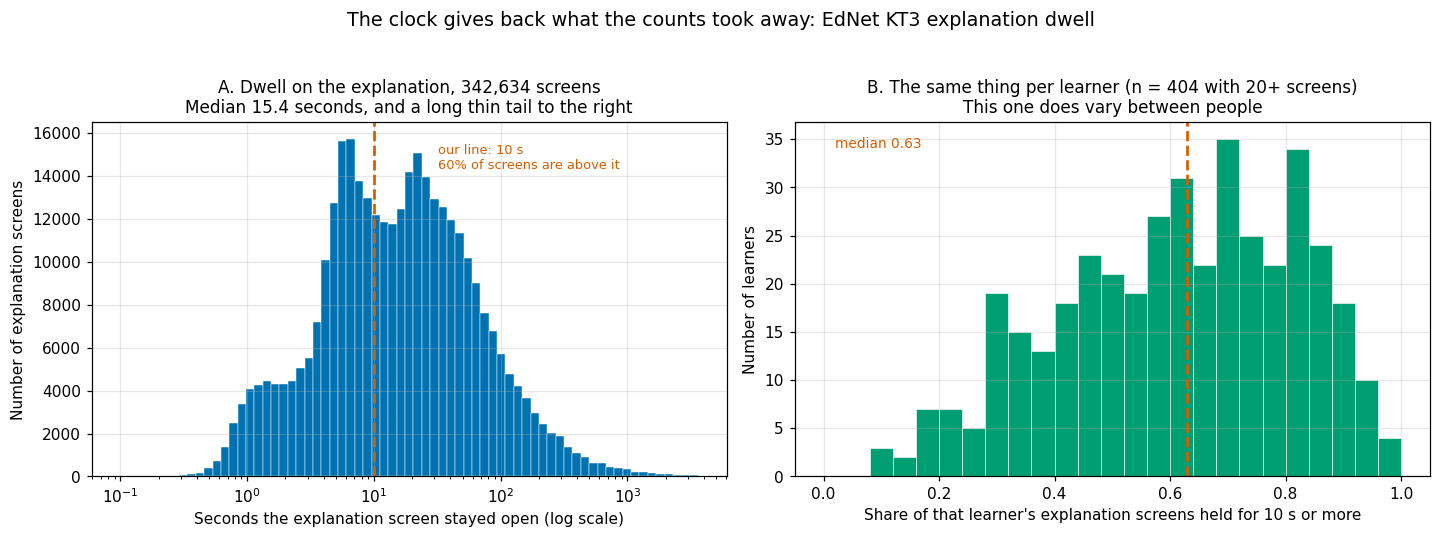

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))

ax = axes[0]
d = opened['dwell_s'][opened['dwell_s'] > 0]
bins = np.logspace(np.log10(0.1), np.log10(3600), 70)
ax.hist(d, bins=bins, color=BLUE, edgecolor='white', linewidth=0.3)
ax.axvline(STAY_SECONDS, color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(STAY_SECONDS * 3.2, ax.get_ylim()[1] * 0.94,
        'our line: %d s\n%.0f%% of screens are above it' % (STAY_SECONDS,
                                                            (opened['dwell_s'] >= STAY_SECONDS).mean() * 100),
        fontsize=8.5, color=VERMILLION, va='top')
ax.set_xscale('log')
ax.set_xlabel('Seconds the explanation screen stayed open (log scale)')
ax.set_ylabel('Number of explanation screens')
ax.set_title('A. Dwell on the explanation, 342,634 screens\nMedian 15.4 seconds, and a long thin tail to the right')

ax = axes[1]
ax.hist(enough['share_stayed'], bins=np.linspace(0, 1, 26), color=GREEN,
        edgecolor='white', linewidth=0.4)
ax.axvline(enough['share_stayed'].median(), color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(0.02, ax.get_ylim()[1] * 0.96,
        'median %.2f' % enough['share_stayed'].median(), fontsize=9, color=VERMILLION,
        va='top', ha='left')
ax.set_xlabel('Share of that learner\'s explanation screens held for %d s or more' % STAY_SECONDS)
ax.set_ylabel('Number of learners')
ax.set_title('B. The same thing per learner (n = %d with 20+ screens)\nThis one does vary between people' % len(enough))

fig.suptitle('The clock gives back what the counts took away: EdNet KT3 explanation dwell',
             fontsize=12.5, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation prompt.**

1. Panel A: 8.7 percent of explanation screens close within two seconds and 40.2 percent close within ten. **Do not write the sentence you want to write.** A screen closed in one second is a screen closed in one second. Name three reasons a person on a phone closes a screen fast, and put "did not want the help" last on the list where it belongs.
2. Panel B is the first measure in this notebook with genuine spread that the app does not obviously impose: from 0.316 at the tenth percentile to 0.866 at the ninetieth. Would you put this on a dashboard? Write the label you would give the column, in words a tutor would read correctly.
3. The interval on the median comes from resampling **learners**, not screens. Explain, to a colleague who wants to resample the 342,634 screens because it gives a tighter interval, why they are wrong.
4. 96 of 500 learners are excluded from panel B, and the notebook says they are not missing at random. What does that do to the sentence "the typical learner stays on about 63 percent of explanations"? Rewrite it so it is true.

### 7.1 The test that fails, and why that is the good part

Here is a hypothesis worth stating before you test it, because you will believe it:

> An explanation the learner **opened themselves** should hold their attention longer than one the app **put in front of them**. Choosing help is a regulation move; being handed it is not.

Section 5 gives us the split. An explanation screen either follows a submit of the same bundle, in which case the app opened it, or it does not, in which case something else did. Compare the dwell.

Because dwell varies enormously between people, the comparison is made **within each learner** and then summarised across learners, with an interval from resampling learners.

In [20]:
pair = (opened.groupby(['user_id', 'opened_by_the_flow'])['dwell_s']
        .agg(['median', 'size']).unstack())
pair.columns = ['median_other', 'median_flow', 'n_other', 'n_flow']
pair = pair.dropna()
pair = pair[(pair['n_flow'] >= 20) & (pair['n_other'] >= 20)]
diff = pair['median_other'] - pair['median_flow']

print('Pooled over all %s explanation screens:' % format(len(opened), ','))
print('   opened by the flow (right after that bundle\'s submit): %s screens, median %.2f s'
      % (format(int(opened['opened_by_the_flow'].sum()), ','),
         opened.loc[opened['opened_by_the_flow'], 'dwell_s'].median()))
print('   opened some other way                                : %s screens, median %.2f s'
      % (format(int((~opened['opened_by_the_flow']).sum()), ','),
         opened.loc[~opened['opened_by_the_flow'], 'dwell_s'].median()))
print()
print('WITHIN LEARNER, among the %d learners with at least 20 screens of each kind:' % len(pair))
print('   median of (other minus flow) in median dwell: %+.2f s' % diff.median())
print('   learners where "other" is longer            : %d of %d (%.1f%%)'
      % (int((diff > 0).sum()), len(diff), (diff > 0).mean() * 100))
rng = np.random.default_rng(8100)
bd = np.array([np.median(diff.values[rng.integers(0, len(diff), len(diff))]) for _ in range(4000)])
print('   bootstrap 95%% interval, resampling learners: [%+.2f, %+.2f] seconds'
      % (np.percentile(bd, 2.5), np.percentile(bd, 97.5)))
print()
print('The interval sits entirely below zero. The hypothesis is not merely unsupported.')
print('It is contradicted, and by a lot.')

Pooled over all 342,634 explanation screens:
   opened by the flow (right after that bundle's submit): 295,035 screens, median 16.49 s
   opened some other way                                : 47,599 screens, median 8.31 s

WITHIN LEARNER, among the 258 learners with at least 20 screens of each kind:
   median of (other minus flow) in median dwell: -7.77 s
   learners where "other" is longer            : 50 of 258 (19.4%)
   bootstrap 95% interval, resampling learners: [-9.76, -5.50] seconds

The interval sits entirely below zero. The hypothesis is not merely unsupported.
It is contradicted, and by a lot.


Where an explanation screen comes from, and how long it stays open
                                           screens  median_dwell_s  pct_held_10s_plus  pct_of_all_screens
opened_after                                                                                             
right after submitting that bundle          295035          16.488               62.0                86.1
reopened the one just closed                 26131           6.503               40.4                 7.6
opened a different explanation               17878          12.020               53.4                 5.2
right after submitting a different bundle     1927          16.013               58.6                 0.6
right after closing a lecture                 1652          10.129               50.2                 0.5
first action in this learner's log              11          52.258               81.8                 0.0

There it is. 54.9% of the screens that were NOT opened by the flow are the learner
r

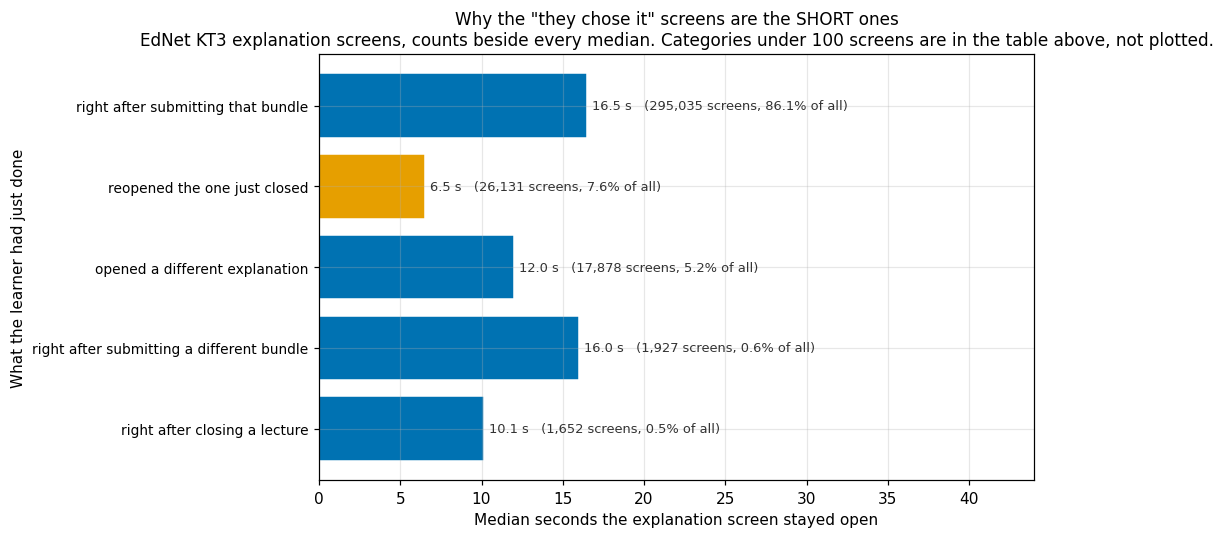

In [21]:
# Why. Split "some other way" by what the learner had just been doing.
prev_state_all = actions['event'].shift()
prev_num_all = actions['item_num'].shift()
same_prev_all = actions['user_id'] == actions['user_id'].shift()

origin = pd.Series('first action in this learner\'s log', index=actions.index)
origin[same_prev_all & (prev_state_all == 'submit_b')
       & (prev_num_all == actions['item_num'])] = 'right after submitting that bundle'
origin[same_prev_all & (prev_state_all == 'submit_b')
       & (prev_num_all != actions['item_num'])] = 'right after submitting a different bundle'
origin[same_prev_all & (prev_state_all == 'quit_e')
       & (prev_num_all == actions['item_num'])] = 'reopened the one just closed'
origin[same_prev_all & (prev_state_all == 'quit_e')
       & (prev_num_all != actions['item_num'])] = 'opened a different explanation'
origin[same_prev_all & (prev_state_all == 'quit_l')] = 'right after closing a lecture'
opened['opened_after'] = origin.reindex(opened['index']).values

breakdown = opened.groupby('opened_after').agg(
    screens=('dwell_s', 'size'),
    median_dwell_s=('dwell_s', 'median'),
    pct_held_10s_plus=('dwell_s', lambda s: round((s >= 10).mean() * 100, 1)))
breakdown['pct_of_all_screens'] = (breakdown['screens'] / len(opened) * 100).round(1)
breakdown = breakdown.sort_values('screens', ascending=False)
print('Where an explanation screen comes from, and how long it stays open')
print(breakdown.to_string())
print()
print('There it is. %.1f%% of the screens that were NOT opened by the flow are the learner'
      % (100 * breakdown.loc['reopened the one just closed', 'screens']
         / int((~opened['opened_by_the_flow']).sum())))
print('reopening the explanation they had just closed, a median of %.1f s each.'
      % breakdown.loc['reopened the one just closed', 'median_dwell_s'])
print('Flicking back is not deliberation. The label "opened it themselves" was ours, not the log\'s.')

plotted = breakdown[breakdown['screens'] >= 100]
fig, ax = plt.subplots(figsize=(9.6, 5.0))
order = list(plotted.index)
pos = np.arange(len(order))
colours = [ORANGE if o == 'reopened the one just closed' else BLUE for o in order]
ax.barh(pos, plotted['median_dwell_s'], color=colours, edgecolor='white')
for i, o in enumerate(order):
    ax.text(plotted.loc[o, 'median_dwell_s'] + 0.3, i,
            '%.1f s   (%s screens, %.1f%% of all)'
            % (plotted.loc[o, 'median_dwell_s'],
               format(int(plotted.loc[o, 'screens']), ','),
               plotted.loc[o, 'pct_of_all_screens']),
            va='center', fontsize=8.5, color=BLACK)
ax.set_yticks(pos)
ax.set_yticklabels(order, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 44)
ax.set_xlabel('Median seconds the explanation screen stayed open')
ax.set_ylabel('What the learner had just done')
ax.set_title('Why the "they chose it" screens are the SHORT ones\n'
             'EdNet KT3 explanation screens, counts beside every median. '
             'Categories under 100 screens are in the table above, not plotted.')
plt.tight_layout()
plt.show()

**Interpretation prompt.** A hypothesis died here and the notebook is better for it.

1. State the hypothesis, state the result, and state the reason in one sentence each. Then answer the question that matters: **was the hypothesis wrong, or was the operationalisation wrong?** They call for different repairs.
2. `reopened the one just closed` is 26,131 screens at a median of 6.5 seconds. Give an interface explanation for a person opening and instantly reclosing the same screen. Now give a second. You should not need a single sentence about motivation to explain either.
3. Notice how the pooled comparison and the within-learner comparison agree in direction here. Construct, on paper, a case where they would **disagree**, and say which one you would report.
4. **The move to keep.** Before a split becomes a variable, look at what is actually in each side of it. We nearly published "learners who seek help engage less with it", and the truth was "flicking back is quick".

### 7.2 Time to the first answer

One more timing measure, and this one is about the answering rather than the help: the seconds between a bundle opening and the first answer inside it.

This is the single stretch of a KT3 log that plausibly contains reading and thinking. It is worth knowing how much of the log it is.

Bundles with a timed first answer: 300,374 of 314,791 episodes

Seconds from the bundle opening to the first answer:
   10th percentile :      8.5 s
   25th percentile :     13.1 s
   50th percentile :     19.0 s
   75th percentile :     32.2 s
   90th percentile :     66.2 s
   99th percentile :    203.5 s
   share under 3 seconds : 0.013  (3,939 bundles)
   share over 5 minutes  : 0.0045  (1,364 bundles)

Per learner, among the 415 learners with at least 20 timed bundles:
   10th percentile of the per-learner medians :   15.3 s
   25th percentile of the per-learner medians :   17.6 s
   50th percentile of the per-learner medians :   20.1 s
   75th percentile of the per-learner medians :   23.2 s
   90th percentile of the per-learner medians :   27.6 s


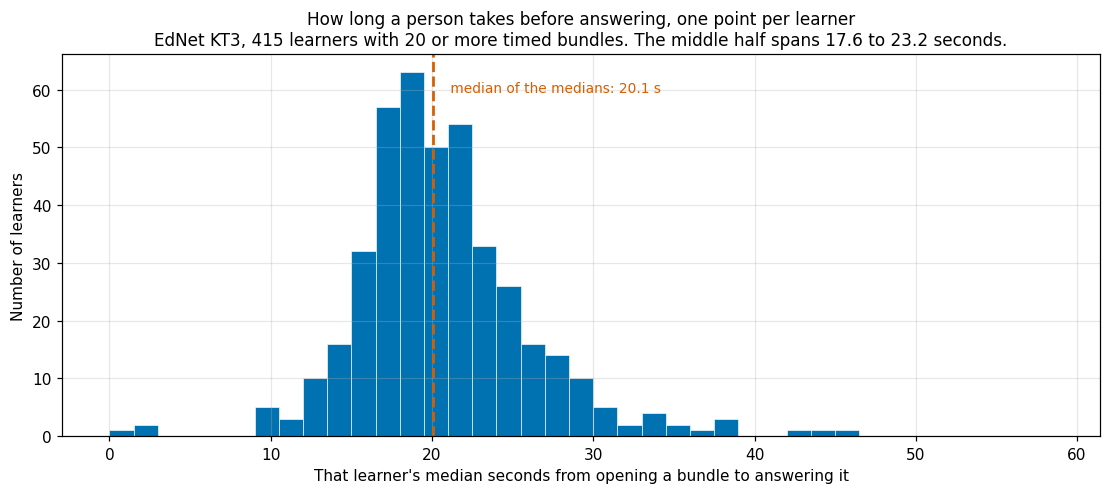

In [22]:
episode_start = inside[inside['event'] == 'enter_b'].groupby('episode')['timestamp'].first()
first_answer = inside[inside['event'] == 'respond_q'].groupby('episode')['timestamp'].first()
episode_user = inside[inside['event'] == 'enter_b'].groupby('episode')['user_id'].first()

time_to_answer = ((first_answer - episode_start) / 1000.0).dropna()
tta = pd.DataFrame({'seconds': time_to_answer})
tta['user_id'] = tta.index.map(episode_user)

print('Bundles with a timed first answer: %s of %s episodes'
      % (format(len(tta), ','), format(int(actions['episode'].max()), ',')))
print()
print('Seconds from the bundle opening to the first answer:')
for p in [10, 25, 50, 75, 90, 99]:
    print('   %2dth percentile : %8.1f s' % (p, np.percentile(tta['seconds'], p)))
print('   share under 3 seconds : %.3f  (%s bundles)'
      % ((tta['seconds'] < 3).mean(), format(int((tta['seconds'] < 3).sum()), ',')))
print('   share over 5 minutes  : %.4f  (%s bundles)'
      % ((tta['seconds'] > 300).mean(), format(int((tta['seconds'] > 300).sum()), ',')))

pl_tta = tta.groupby('user_id')['seconds'].agg(['median', 'size'])
pl_tta = pl_tta[pl_tta['size'] >= 20]
print()
print('Per learner, among the %d learners with at least 20 timed bundles:' % len(pl_tta))
for p in [10, 25, 50, 75, 90]:
    print('   %2dth percentile of the per-learner medians : %6.1f s'
          % (p, np.percentile(pl_tta['median'], p)))

fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.hist(pl_tta['median'], bins=np.arange(0, 60, 1.5), color=BLUE, edgecolor='white', linewidth=0.4)
ax.axvline(pl_tta['median'].median(), color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(pl_tta['median'].median() + 0.8, ax.get_ylim()[1] * 0.9,
        ' median of the medians: %.1f s' % pl_tta['median'].median(), fontsize=9, color=VERMILLION)
ax.set_xlabel('That learner\'s median seconds from opening a bundle to answering it')
ax.set_ylabel('Number of learners')
ax.set_title('How long a person takes before answering, one point per learner\n'
             'EdNet KT3, %d learners with 20 or more timed bundles. The middle half spans %.1f to %.1f seconds.'
             % (len(pl_tta), pl_tta['median'].quantile(.25), pl_tta['median'].quantile(.75)))
plt.tight_layout()
plt.show()

**Interpretation prompt.**

1. The middle half of learners have a median time to answer between 17.6 and 23.2 seconds. That is a **narrow** band for 415 people studying alone on their phones over fifteen months. Give the instrument explanation first, then the setting explanation, and only then consider whether it says anything about people.
2. 1.3 percent of bundles are answered within three seconds. The field has a phrase for patterns like this. It calls them **"gaming the system"** and describes them as **"hint spam"**, and those phrases are in the titles of well-cited papers. Notice what each phrase does: it names a motive that no timestamp can see, and it names it before any evidence has been offered. This course quotes those terms and does not speak in them. What we can say is what was recorded: **an answer arriving within three seconds of the question appearing**. Write down three things that produce such a row, and make at least two of them properties of the item or the app.
3. Compare the spread here with the spread in the explanation dwell chart. One of these measures separates people and one does not. Which would you build a study on, and what does the other one still tell you?
4. Return to Winne. Of everything you have computed today, name the measure you would defend as evidence about **self-regulation** rather than about activity, and state the single strongest objection to your own choice.

### ✏️ Your turn 4

Section 7 hangs on a line you did not choose: **how many seconds counts as staying on the explanation**. Ten was our pick. It is a real decision, since it moves both the headline and who sits at the bottom of it.

The cell ships with **5 seconds**, deliberately different from the notebook's 10.

In [23]:
# ✏️ TODO: change this and rerun. Try 2, then 5, then 10, then 30.
MY_STAY_SECONDS = 5

mine_stay = opened.groupby('user_id').agg(
    screens=('dwell_s', 'size'),
    share=('dwell_s', lambda s: (s >= MY_STAY_SECONDS).mean()))
mine_stay = mine_stay[mine_stay['screens'] >= 20]

print('Your line: a screen "stayed on" if it was held for %d seconds or more.' % MY_STAY_SECONDS)
print("The notebook's line: %d seconds." % STAY_SECONDS)
print()
print('                                                       yours    notebook')
print('learners summarised (20+ screens)                  %9d %11d' % (len(mine_stay), len(enough)))
print('share of ALL screens above the line                %9.3f %11.3f'
      % ((opened['dwell_s'] >= MY_STAY_SECONDS).mean(), (opened['dwell_s'] >= STAY_SECONDS).mean()))
print('median per-learner share                           %9.3f %11.3f'
      % (mine_stay['share'].median(), enough['share_stayed'].median()))
print('learners in the bottom decile on this measure      %9d %11d'
      % (int((mine_stay['share'] <= mine_stay['share'].quantile(.10)).sum()),
         int((enough['share_stayed'] <= enough['share_stayed'].quantile(.10)).sum())))

bottom_mine = set(mine_stay.index[mine_stay['share'] <= mine_stay['share'].quantile(.10)])
bottom_nb = set(enough.index[enough['share_stayed'] <= enough['share_stayed'].quantile(.10)])
print()
print('Learners in the bottom decile under BOTH lines : %d' % len(bottom_mine & bottom_nb))
print('Learners in the bottom decile under only ONE   : %d'
      % len(bottom_mine.symmetric_difference(bottom_nb)))
print()
print('That last number is the exercise. Those are people whose label depends on a threshold')
print('somebody chose in an afternoon. Write down what you would owe them before a system')
print('that used this measure was allowed to say anything about them to anyone.')

Your line: a screen "stayed on" if it was held for 5 seconds or more.
The notebook's line: 10 seconds.

                                                       yours    notebook
learners summarised (20+ screens)                        404         404
share of ALL screens above the line                    0.789       0.598
median per-learner share                               0.887       0.629
learners in the bottom decile on this measure             41          41

Learners in the bottom decile under BOTH lines : 19
Learners in the bottom decile under only ONE   : 44

That last number is the exercise. Those are people whose label depends on a threshold
somebody chose in an afternoon. Write down what you would owe them before a system
that used this measure was allowed to say anything about them to anyone.


## 💬 Reflection

Bring written answers to at least two of these. They are the spine of tonight's discussion.

**On Winne (2022), "Learning analytics for self-regulated learning."**
Winne argues that self-regulated learning is not directly observable and that traces are the footprints it leaves. Today you had 1,893,105 footprints and no answer key. Name the measure you built that comes closest to evidence about regulation, and then state precisely what would have to be true of the Santa interface for that measure to mean what you want it to mean. Then the version with teeth: about one of the 42 learners who never opened an explanation, what have you actually learned?

**On Zhang, Borchers, and Barany (2024), "Studying the interplay of self-regulated learning cycles and scaffolding through ordered network analysis across three tutoring systems."**
Their analysis is about how regulation cycles interact with the scaffolding a system offers, compared across three different tutors. Section 5 of this notebook found that Santa's central piece of scaffolding, the explanation, is not requested at all: it is delivered, at a speed that depends on whether you are holding a phone. Using that finding, argue either that the scaffolding here is shaping the regulation we measured rather than revealing it, or that the distinction cannot be drawn from a log of this kind. Whichever you argue, say what a comparison across three systems would have to hold constant for it to be fair.

**On Viberg, Khalil, and Baars (2020), "Self-regulated learning and learning analytics in online learning environments."**
Their review asks how much work on SRL measures SRL and how much of it measures activity wearing an SRL vocabulary. Turn that on today. You built four candidate measures: the action profile, bundles per sitting, explanation dwell, and time to first answer. Rank them from "activity with a nicer name" to "defensible evidence about regulation", and defend the ordering. At least one of them should be at the bottom for a reason you can state in a sentence.

**Across the three, and across the course.**
In Week 3 we found that bias entered a model of non-completion through a feature choice rather than through the algorithm. Today the notebook made at least six choices: thirty minutes for a session, ten seconds for staying on an explanation, ten answers per question for the concentration comparison, twenty screens to summarise a learner, which two of the seven events to leave out of the profile, and which comparisons to make within learner rather than across rows. Pick the one you think is most consequential and least defensible, and say what evidence would settle it.

Then a seventh, which is not a modelling choice at all. Section 5 showed that "number of explanations opened" ranks learners at Spearman 0.995 with "amount of app use". If a vendor shipped that as an engagement metric, would they be lying? Answer carefully, because the interesting answer is not yes.

### A question for our guest

Conrad Borchers joins us this week and is a coauthor of the Zhang, Borchers, and Barany reading. [Bio: confirm with speaker]

Come with a real question. The strongest ones come from something you just did with your own hands. Ours came out of Section 3: every session statistic in this notebook moved by a factor of two or three when the gap rule moved, and ordered network analysis rests on a window choice of the same kind. So:

> "Ordered network analysis connects actions inside a window that the analyst chooses, and our own session rule moved every headline by a factor of two or three when we moved it. When you compare regulation cycles across three tutoring systems whose interfaces pace their users differently, how do you keep the window from doing the comparing for you? Is there a defensible way to report that sensitivity, or does the field have to trust the analyst?"

Write your own version, or a better one. Bring it on paper.

## ✅ Before you leave today

**There is nothing to upload to Canvas this week.** Week 7 has no mini project. This lab is a launch: we start it together in class and you finish reading and arguing with it on your own time. The next Canvas deliverable is Mini Project 4, due Week 8.

Checklist for tonight:

- [ ] The notebook ran top to bottom with no errors (**Runtime > Restart and run all**).
- [ ] You can state, from memory, **what one row of EdNet KT3 is** and **what is not in the file**. The second half of that sentence is the one that matters.
- [ ] You can explain the **explanation artifact** to somebody who was not here: why "number of explanations opened" is a volume measure, and what the 0.077 second median has to do with it.
- [ ] You can explain the **repeat answer artifact**: why an accuracy comparison between answers given with and without help would have measured a logging convention.
- [ ] You changed at least one value in a **✏️ Your turn** cell and noticed what moved. Ideally you noticed something that did **not** move as well.
- [ ] You have written answers to at least two 💬 Reflection prompts.
- [ ] You have one question written down for Conrad Borchers.
- [ ] You remember that this file is **CC BY-NC 4.0**. Attribution to Choi and colleagues (2020), non-commercial use only, and nothing built on it leaves this course.

**AI use, per the course policy.** AI assistance is permitted in designated activities and must be documented. There is no submission this week, so there is nothing to log today. The moment any of this code, or any AI conversation about it, makes its way into a mini project or your course research project, the full policy applies: you upload your AI interaction log and a short reflection alongside the work. Undisclosed use is an Honor Code violation. The habit that makes this painless is keeping the log as you go rather than reconstructing it afterward.

## Appendix: solutions to the ✏️ Your turn cells

These are worked versions, not the only right answers. Run them after you have tried your own.

### Solution 1: several learners at once, with counts kept next to the percentages

One learner against a median is a start. A handful side by side makes the point that a profile is mostly the app, with one column that is not.

In [24]:
SOME_LEARNERS = list(counts.sum(axis=1).sort_values(ascending=False).index[:3]) + ['u170']

side = (share.loc[SOME_LEARNERS].round(1).T)
side.index = [LABEL[e] for e in side.index]
side['class median'] = share.median().round(1).values
print('Percent of each learner\'s own events (with the class median in the last column)')
print(side.to_string())
print()
print('And the same learners in raw counts, because a percentage of 40,000 events and a')
print('percentage of 400 are not the same kind of statement:')
raw = counts.loc[SOME_LEARNERS].T
raw.index = [LABEL[e] for e in raw.index]
print(raw.to_string())
print()
spread = share.std().round(2)
print('Standard deviation across the 500 learners, by event:')
for e in EVENTS:
    print('   %-22s %5.2f percentage points' % (LABEL[e], spread[e]))
print()
print('The explanation column has %.1f times the spread of the bundle-opening column.'
      % (spread['enter_e'] / spread['enter_b']))
print('Everything else is the app moving people along rails.')

Percent of each learner's own events (with the class median in the last column)
user_id              u226  u371  u493  u170  class median
opened a bundle       5.2  18.9  20.1  22.3          23.4
answered a question  82.9  30.9  34.3  29.9          29.8
submitted a bundle    5.2  18.9  20.1  22.3          23.4
explanation opened    6.7  31.1  24.4  18.6          22.3
opened a lecture      0.1   0.2   1.0   6.9           0.8

And the same learners in raw counts, because a percentage of 40,000 events and a
percentage of 400 are not the same kind of statement:
user_id               u226  u371  u493  u170
opened a bundle       2562  5545  5601    71
answered a question  41071  9051  9534    95
submitted a bundle    2562  5545  5601    71
explanation opened    3308  9138  6784    59
opened a lecture        53    59   285    22

Standard deviation across the 500 learners, by event:
   opened a bundle         4.28 percentage points
   answered a question     7.25 percentage points
   submitte

### Solution 2: the session rule as a surface, not a point

One threshold at a time is fine for exploring. For an argument you want the whole curve, because a reader is entitled to know whether your result sits on a plateau or on a slope.

           sessions  bundles per sitting  minutes per sitting  sessions per learner
gap (min)                                                                          
1            171183                 1.00                 0.72                 117.0
2             93403                 2.00                 2.33                  71.0
5             48578                 5.00                 6.54                  37.0
10            33420                 7.00                10.59                  27.0
15            28852                 7.75                13.02                  24.0
20            26431                 8.00                14.23                  22.0
30            23810                 8.75                16.02                  19.0
45            21674                 9.00                17.86                  19.0
60            20426                10.00                19.28                  17.5
90            18703                10.00                20.61               

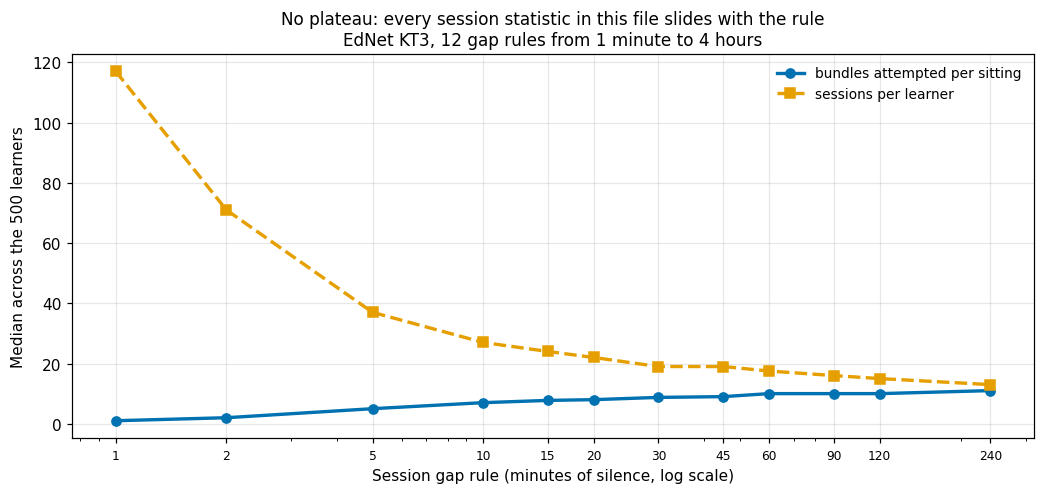

In [25]:
sweep = []
for m in [1, 2, 5, 10, 15, 20, 30, 45, 60, 90, 120, 240]:
    _, s = sessionise(m)
    pl = s.groupby('user_id').agg(n=('n_actions', 'size'), b=('bundles', 'median'),
                                  mi=('minutes', 'median'))
    sweep.append({'gap (min)': m, 'sessions': len(s),
                  'bundles per sitting': pl['b'].median(),
                  'minutes per sitting': round(pl['mi'].median(), 2),
                  'sessions per learner': pl['n'].median()})
sweep = pd.DataFrame(sweep).set_index('gap (min)')
print(sweep.to_string())
print()
print('Read down the "bundles per sitting" column. There is no plateau anywhere in the')
print('defensible range, so there is no threshold you could call robust. The correct way to')
print('report a session statistic from this file is with the rule attached to it, always.')

fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(sweep.index, sweep['bundles per sitting'], marker='o', color=BLUE, linewidth=2.2,
        label='bundles attempted per sitting')
ax.plot(sweep.index, sweep['sessions per learner'], marker='s', color=ORANGE, linewidth=2.2,
        linestyle='--', label='sessions per learner')
ax.set_xscale('log')
ax.set_xticks(sweep.index)
ax.set_xticklabels([str(v) for v in sweep.index], fontsize=8)
ax.set_xlabel('Session gap rule (minutes of silence, log scale)')
ax.set_ylabel('Median across the 500 learners')
ax.set_title('No plateau: every session statistic in this file slides with the rule\n'
             'EdNet KT3, 12 gap rules from 1 minute to 4 hours')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### Solution 3: does the concentration finding survive every threshold you could defend?

Sweeping the minimum-answers threshold trades the number of questions against the noise in each one. A finding that holds across the sweep is a different kind of claim from one that does not.

One thing to hold in mind while you read the sweep: every row of it is an **unmatched** comparison, so every difference in it carries the sample-size inflation that Section 6 measured and removed. The sweep tells you how the comparison behaves as the filter tightens. It does not remove the bias, and neither does raising the threshold, because the bar applies to both conditions separately and the post-explanation side stays the smaller of the two.

In [26]:
rows = []
for m in [5, 10, 15, 20, 25, 30, 40, 50]:
    a = modal_share_at(first_exposure, m)
    b = modal_share_at(after_shown, m)
    qq = a.index.intersection(b.index)
    if len(qq) < 3:
        rows.append({'min answers': m, 'questions': len(qq), 'first exposure': np.nan,
                     'after explanation': np.nan, 'difference': np.nan, '% rising': np.nan})
        continue
    d = b[qq] - a[qq]
    rows.append({'min answers': m, 'questions': len(qq),
                 'first exposure': round(a[qq].median(), 3),
                 'after explanation': round(b[qq].median(), 3),
                 'difference': round(d.median(), 3),
                 '% rising': round((d > 0).mean() * 100, 1)})
print(pd.DataFrame(rows).set_index('min answers').to_string())
print()
print('The gap widens as the bar rises, and the number of questions collapses. Both are')
print('expected: stricter thresholds keep the questions many people answered twice, which')
print('are exactly the ones the app pushed back at them. Say that out loud when you report it,')
print('because it means the sweep is not a robustness check so much as a description of')
print('which questions survive the filter.')

             questions  first exposure  after explanation  difference  % rising
min answers                                                                    
5                 3295           0.582              0.714       0.121      75.2
10                1241           0.551              0.700       0.136      81.6
15                 611           0.530              0.697       0.150      84.9
20                 324           0.514              0.692       0.153      84.9
25                 190           0.502              0.689       0.158      86.3
30                 104           0.474              0.667       0.184      86.5
40                  39           0.468              0.635       0.165      79.5
50                  12           0.522              0.645       0.164      66.7

The gap widens as the bar rises, and the number of questions collapses. Both are
expected: stricter thresholds keep the questions many people answered twice, which
are exactly the ones the app pushed

### Solution 4: how much of the bottom decile is the threshold?

The point of Your turn 4 is that a label can be an artifact of a line somebody drew. Here is the whole picture rather than one comparison: how stable is membership of the bottom decile across every defensible line?

Learners in the bottom decile of "share of explanations stayed on", by threshold:
    2 s : 41 learners
    3 s : 41 learners
    5 s : 41 learners
   10 s : 41 learners
   15 s : 42 learners
   20 s : 41 learners
   30 s : 41 learners

In the bottom decile under EVERY threshold : 5 learners
In the bottom decile under AT LEAST ONE    : 85 learners
So 80 of the 85 people who could ever be labelled are labelled by the threshold
rather than by anything stable about their record. That is 94% of them.


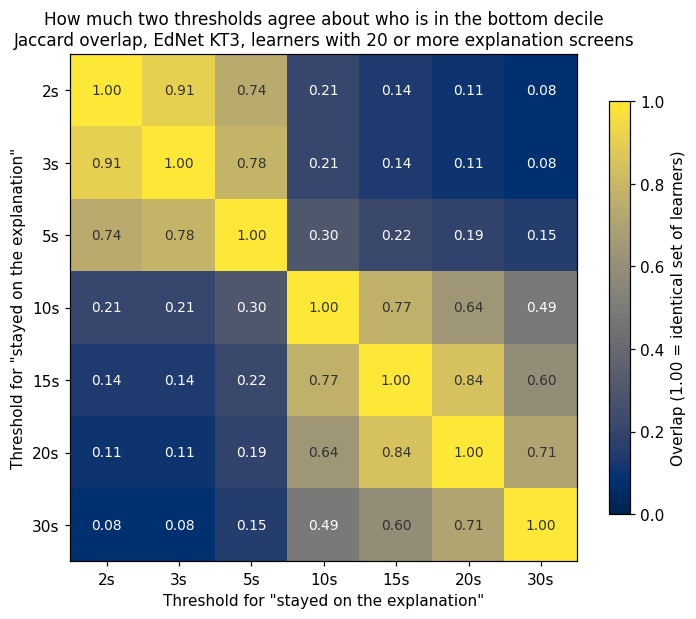

In [27]:
lines = [2, 3, 5, 10, 15, 20, 30]
members = {}
for t in lines:
    s = opened.groupby('user_id').agg(screens=('dwell_s', 'size'),
                                      share=('dwell_s', lambda x: (x >= t).mean()))
    s = s[s['screens'] >= 20]
    members[t] = set(s.index[s['share'] <= s['share'].quantile(.10)])

print('Learners in the bottom decile of "share of explanations stayed on", by threshold:')
for t in lines:
    print('   %2d s : %d learners' % (t, len(members[t])))
print()
always = set.intersection(*members.values())
ever = set.union(*members.values())
print('In the bottom decile under EVERY threshold : %d learners' % len(always))
print('In the bottom decile under AT LEAST ONE    : %d learners' % len(ever))
print('So %d of the %d people who could ever be labelled are labelled by the threshold'
      % (len(ever) - len(always), len(ever)))
print('rather than by anything stable about their record. That is %.0f%% of them.'
      % (100 * (len(ever) - len(always)) / len(ever)))

overlap = pd.DataFrame(index=lines, columns=lines, dtype=float)
for a in lines:
    for b in lines:
        overlap.loc[a, b] = len(members[a] & members[b]) / len(members[a] | members[b])
fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(overlap.values.astype(float), cmap='cividis', vmin=0, vmax=1)
ax.set_xticks(range(len(lines)))
ax.set_xticklabels(['%ds' % t for t in lines])
ax.set_yticks(range(len(lines)))
ax.set_yticklabels(['%ds' % t for t in lines])
for i in range(len(lines)):
    for j in range(len(lines)):
        v = overlap.values[i, j]
        ax.text(j, i, '%.2f' % v, ha='center', va='center', fontsize=9,
                color='white' if v < 0.55 else BLACK)
ax.set_xlabel('Threshold for "stayed on the explanation"')
ax.set_ylabel('Threshold for "stayed on the explanation"')
ax.set_title('How much two thresholds agree about who is in the bottom decile\n'
             'Jaccard overlap, EdNet KT3, learners with 20 or more explanation screens')
fig.colorbar(im, ax=ax, shrink=0.8, label='Overlap (1.00 = identical set of learners)')
ax.grid(False)
plt.tight_layout()
plt.show()

---

*EDIS 8100: Teaching and Learning Analytics. Course design by Dr. Hakeoung Hannah Lee, University of Virginia School of Education and Human Development.*

*Data: EdNet KT3, a 500-user extract. Choi, Y., Lee, Y., Shin, D., Cho, J., Park, S., Lee, S., Baek, J., Bae, C., Kim, B., & Heo, J. (2020). EdNet: A large-scale hierarchical dataset in education. In* Artificial intelligence in education (AIED 2020), *Lecture Notes in Computer Science 12164 (pp. 69-73). Springer. Licensed CC BY-NC 4.0: attribution required, non-commercial use only.*